# 🇮🇳 Indian Stock Market — Unsupervised Clustering & Descriptive Analytics

**Objective:** Cluster 200 NSE-listed stocks across four annual snapshots (Mar 2023–Mar 2026)  
using P/E, P/B, Debt-to-Equity, PEG, and Market Cap; and answer 10 analytical questions.

**Data source:** India_200.csv (192 stocks across 4 year-ends)

---
## 0. Setup & Imports

In [1]:
# ── Install dependencies if missing ────────────────────────────────────────
import subprocess, sys
pkgs = ['scikit-learn', 'seaborn', 'matplotlib', 'pandas', 'numpy',
        'scipy', 'plotly', 'nbformat']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Global aesthetics ───────────────────────────────────────────────────────
PALETTE = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED',
           '#0891B2','#BE185D','#65A30D','#EA580C','#0F172A']

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.framealpha': 0.9,
})

YEARS  = ['2023-03-31', '2024-03-31', '2025-03-31', '2026-03-31']
YLABELS = ['Mar-2023', 'Mar-2024', 'Mar-2025', 'Mar-2026']
CLUSTER_NAMES = {
    0: 'Value',
    1: 'Growth',
    2: 'Leveraged',
    3: 'Expensive',
    4: 'Large-Cap Stable'
}

print('✅  All libraries loaded successfully.')

✅  All libraries loaded successfully.


---
## 1. Load & Validate Data

In [2]:
RAW = pd.read_csv('India_200.csv')
print(f'Shape: {RAW.shape}  |  Columns: {RAW.columns.tolist()}')
RAW.head(3)

Shape: (192, 31)  |  Columns: ['Ticker', 'Company', 'Closing_Price_2023-03-31', 'Closing_Price_2024-03-31', 'Closing_Price_2025-03-31', 'Closing_Price_2026-03-31', 'EPS_2023-03-31', 'EPS_2024-03-31', 'EPS_2025-03-31', 'EPS_2026-03-31', 'Trailing_PE_2023-03-31', 'Trailing_PE_2024-03-31', 'Trailing_PE_2025-03-31', 'Trailing_PE_2026-03-31', 'BVPS_2023-03-31', 'BVPS_2024-03-31', 'BVPS_2025-03-31', 'BVPS_2026-03-31', 'PB_Ratio_2023-03-31', 'PB_Ratio_2024-03-31', 'PB_Ratio_2025-03-31', 'PB_Ratio_2026-03-31', 'Market_Cap_Cr_2023-03-31', 'Market_Cap_Cr_2024-03-31', 'Market_Cap_Cr_2025-03-31', 'Market_Cap_Cr_2026-03-31', 'Debt_Equity_2023-03-31', 'Debt_Equity_2024-03-31', 'Debt_Equity_2025-03-31', 'Debt_Equity_2026-03-31', 'Industry / Sector']


,Ticker,Company,Closing_Price_2023-03-31,Closing_Price_2024-03-31,Closing_Price_2025-03-31,Closing_Price_2026-03-31,EPS_2023-03-31,EPS_2024-03-31,EPS_2025-03-31,EPS_2026-03-31,...,PB_Ratio_2026-03-31,Market_Cap_Cr_2023-03-31,Market_Cap_Cr_2024-03-31,Market_Cap_Cr_2025-03-31,Market_Cap_Cr_2026-03-31,Debt_Equity_2023-03-31,Debt_Equity_2024-03-31,Debt_Equity_2025-03-31,Debt_Equity_2026-03-31,Industry / Sector
0,3MINDIA,3M India Ltd.,22106.22,30135.09,28401.28,30120.0,395.1802,517.8976,422.6061,357.1593,...,19.19,25229.83,33947.48,31994.33,33930.39,0.0159,0.0085,0.0539,0.0960,Others
1,ABB,ABB India Ltd.,3298.88,6253.62,5479.67,5917.3,47.1790,58.6088,88.3232,143.5853,...,16.00,71057.54,132527.92,116118.64,125399.79,0.0067,0.0082,0.0073,0.0108,Capital Goods
2,ACC,ACC Ltd.,1647.36,2474.62,1934.84,1254.6,34.3212,124.2144,127.8873,94.1954,...,1.15,31171.98,46516.69,36342.29,23559.79,0.0095,0.0217,0.0292,0.0263,Construction Materials


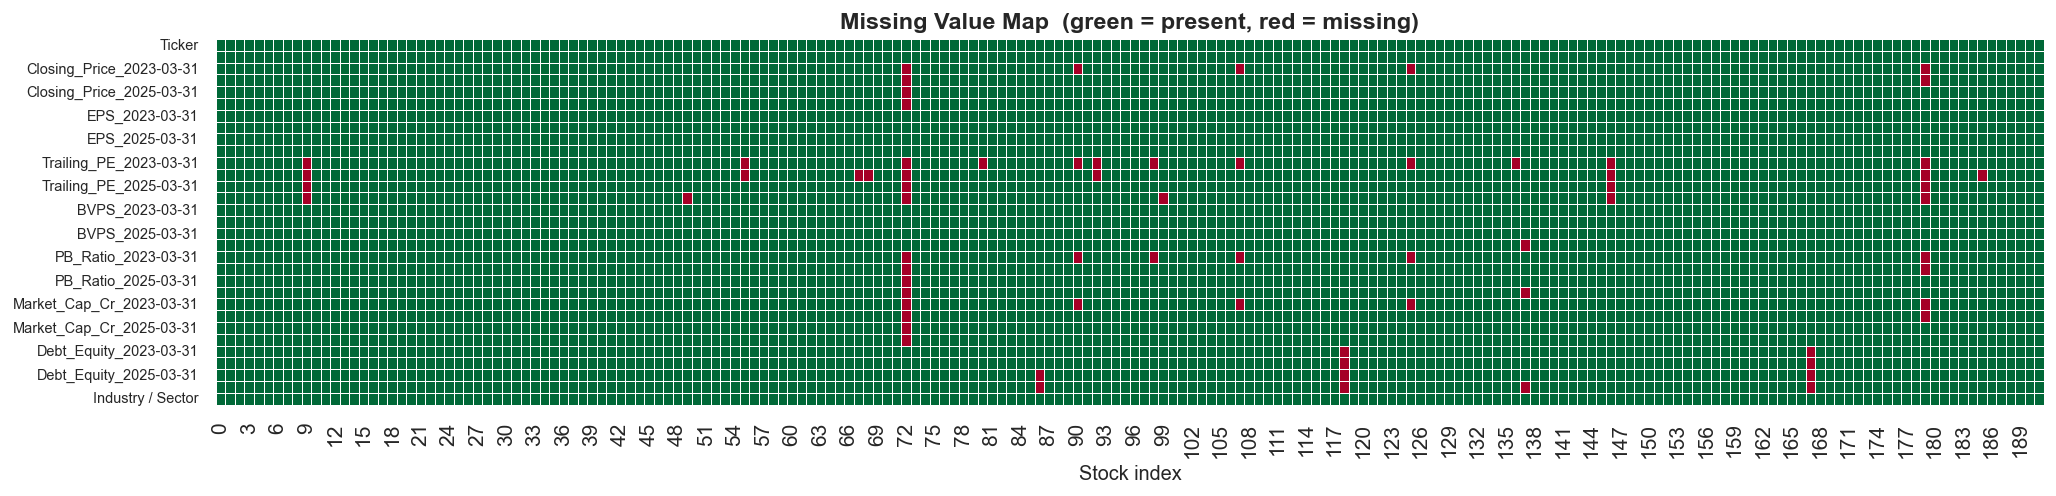


Missing count per column:
Closing_Price_2023-03-31     5
Closing_Price_2024-03-31     2
Closing_Price_2025-03-31     1
Closing_Price_2026-03-31     1
Trailing_PE_2023-03-31      12
Trailing_PE_2024-03-31       9
Trailing_PE_2025-03-31       4
Trailing_PE_2026-03-31       6
BVPS_2026-03-31              1
PB_Ratio_2023-03-31          6
PB_Ratio_2024-03-31          2
PB_Ratio_2025-03-31          1
PB_Ratio_2026-03-31          2
Market_Cap_Cr_2023-03-31     5
Market_Cap_Cr_2024-03-31     2
Market_Cap_Cr_2025-03-31     1
Market_Cap_Cr_2026-03-31     1
Debt_Equity_2023-03-31       2
Debt_Equity_2024-03-31       2
Debt_Equity_2025-03-31       3
Debt_Equity_2026-03-31       4
dtype: int64


In [3]:
# ── Missing-value heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
missing = RAW.isnull().T
sns.heatmap(missing, cbar=False, cmap='RdYlGn_r', ax=ax, linewidths=0.3)
ax.set_title('Missing Value Map  (green = present, red = missing)')
ax.set_xlabel('Stock index')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

print('\nMissing count per column:')
print(RAW.isnull().sum()[RAW.isnull().sum()>0])

---
## 2. Feature Engineering — PEG Ratio & Panel Reshaping

In [4]:
df = RAW.copy()

# ── Compute PEG = PE / EPS_growth (YoY) ────────────────────────────────────
year_pairs = [
    ('2023-03-31', '2024-03-31'),
    ('2024-03-31', '2025-03-31'),
    ('2025-03-31', '2026-03-31'),
]

def safe_peg(pe, eps_t, eps_t1):
    """PEG = PE / EPS_growth%.  Returns NaN when growth ≤ 0 or PE undefined."""
    growth = np.where(
        (eps_t1 > 0) & (eps_t > 0),
        ((eps_t1 - eps_t) / np.abs(eps_t)) * 100,
        np.nan
    )
    peg = np.where(growth > 0, pe / growth, np.nan)
    return peg

# For 2023 we use next-year EPS growth (2023→2024)
df['PEG_2023-03-31'] = safe_peg(
    df['Trailing_PE_2023-03-31'],
    df['EPS_2023-03-31'], df['EPS_2024-03-31'])
# For 2024 use 2023→2024 growth (backward)
df['PEG_2024-03-31'] = safe_peg(
    df['Trailing_PE_2024-03-31'],
    df['EPS_2023-03-31'], df['EPS_2024-03-31'])
df['PEG_2025-03-31'] = safe_peg(
    df['Trailing_PE_2025-03-31'],
    df['EPS_2024-03-31'], df['EPS_2025-03-31'])
df['PEG_2026-03-31'] = safe_peg(
    df['Trailing_PE_2026-03-31'],
    df['EPS_2025-03-31'], df['EPS_2026-03-31'])

# ── Build long (panel) dataframe ────────────────────────────────────────────
FEATURES = ['Trailing_PE', 'PB_Ratio', 'Debt_Equity', 'PEG', 'Market_Cap_Cr']

panels = []
for yr in YEARS:
    tmp = df[['Ticker', 'Company', 'Industry / Sector']].copy()
    tmp['Year'] = yr
    tmp['PE']    = df[f'Trailing_PE_{yr}']
    tmp['PB']    = df[f'PB_Ratio_{yr}']
    tmp['DE']    = df[f'Debt_Equity_{yr}']
    tmp['PEG']   = df[f'PEG_{yr}']
    tmp['MCap']  = df[f'Market_Cap_Cr_{yr}']
    tmp['Price'] = df[f'Closing_Price_{yr}']
    panels.append(tmp)

panel = pd.concat(panels, ignore_index=True)
panel['LogMCap'] = np.log1p(panel['MCap'])
print(f'Panel shape: {panel.shape}')
panel.head()

Panel shape: (768, 11)


,Ticker,Company,Industry / Sector,Year,PE,PB,DE,PEG,MCap,Price,LogMCap
0,3MINDIA,3M India Ltd.,Others,2023-03-31,55.94,15.04,0.0159,1.801406,25229.83,22106.22,10.135822
1,ABB,ABB India Ltd.,Capital Goods,2023-03-31,69.92,14.39,0.0067,2.886101,71057.54,3298.88,11.171259
2,ACC,ACC Ltd.,Construction Materials,2023-03-31,48.00,2.24,0.0095,0.183264,31171.98,1647.36,10.347307
3,ADANIENT,Adani Enterprises Ltd.,Others,2023-03-31,87.99,6.56,1.6040,2.042142,216805.64,1748.05,12.286761
4,ADANIGREEN,Adani Green Energy Ltd.,Power,2023-03-31,143.30,19.11,7.4239,11.170606,139576.80,881.15,11.846377


---
## 3. Descriptive Statistics

In [5]:
# ── Overall summary ──────────────────────────────────────────────────────────
summary_cols = ['PE','PB','DE','PEG','MCap']
overall_desc = panel[summary_cols].describe(percentiles=[.25,.5,.75,.9]).T
overall_desc.style.format('{:.2f}').background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,90%,max
PE,737.00,51.56,159.36,0.84,14.54,28.57,48.90,72.70,1958.97
PB,757.00,9.25,39.93,0.04,1.79,3.77,7.71,14.36,580.54
DE,757.00,0.93,1.91,-7.18,0.06,0.26,0.88,2.59,25.68
PEG,526.00,8.62,68.06,0.00,0.39,1.15,3.14,7.29,1101.93
MCap,759.00,118919.65,183606.69,760.68,31540.95,61888.90,116043.33,273379.02,1810259.12


In [6]:
# ── Yearly descriptive stats table ──────────────────────────────────────────
yearly_stats = []
for yr in YEARS:
    sub = panel[panel['Year'] == yr][summary_cols]
    row = sub.describe().loc[['mean','50%','std']].T
    row.columns = [f'{yr}_{s}' for s in ['Mean','Median','Std']]
    yearly_stats.append(row)

ys_df = pd.concat(yearly_stats, axis=1)
print('=== Yearly Descriptive Statistics ===')
ys_df.style.format('{:.2f}').background_gradient(cmap='YlOrRd', axis=1)

=== Yearly Descriptive Statistics ===


,2023-03-31_Mean,2023-03-31_Median,2023-03-31_Std,2024-03-31_Mean,2024-03-31_Median,2024-03-31_Std,2025-03-31_Mean,2025-03-31_Median,2025-03-31_Std,2026-03-31_Mean,2026-03-31_Median,2026-03-31_Std
PE,50.73,24.84,189.25,57.72,30.83,170.25,52.20,31.27,152.67,45.65,27.34,119.29
PB,8.62,2.99,42.76,10.42,4.39,39.95,9.66,4.21,40.27,8.28,3.74,36.87
DE,0.89,0.26,1.78,1.01,0.23,2.41,0.91,0.28,1.66,0.93,0.27,1.71
PEG,11.79,0.83,94.58,11.48,1.02,86.21,5.21,1.35,17.73,4.70,1.61,18.72
MCap,80419.95,37518.63,132716.99,120895.33,64220.66,169407.55,132946.05,75499.57,204567.05,140621.32,75759.77,211467.10


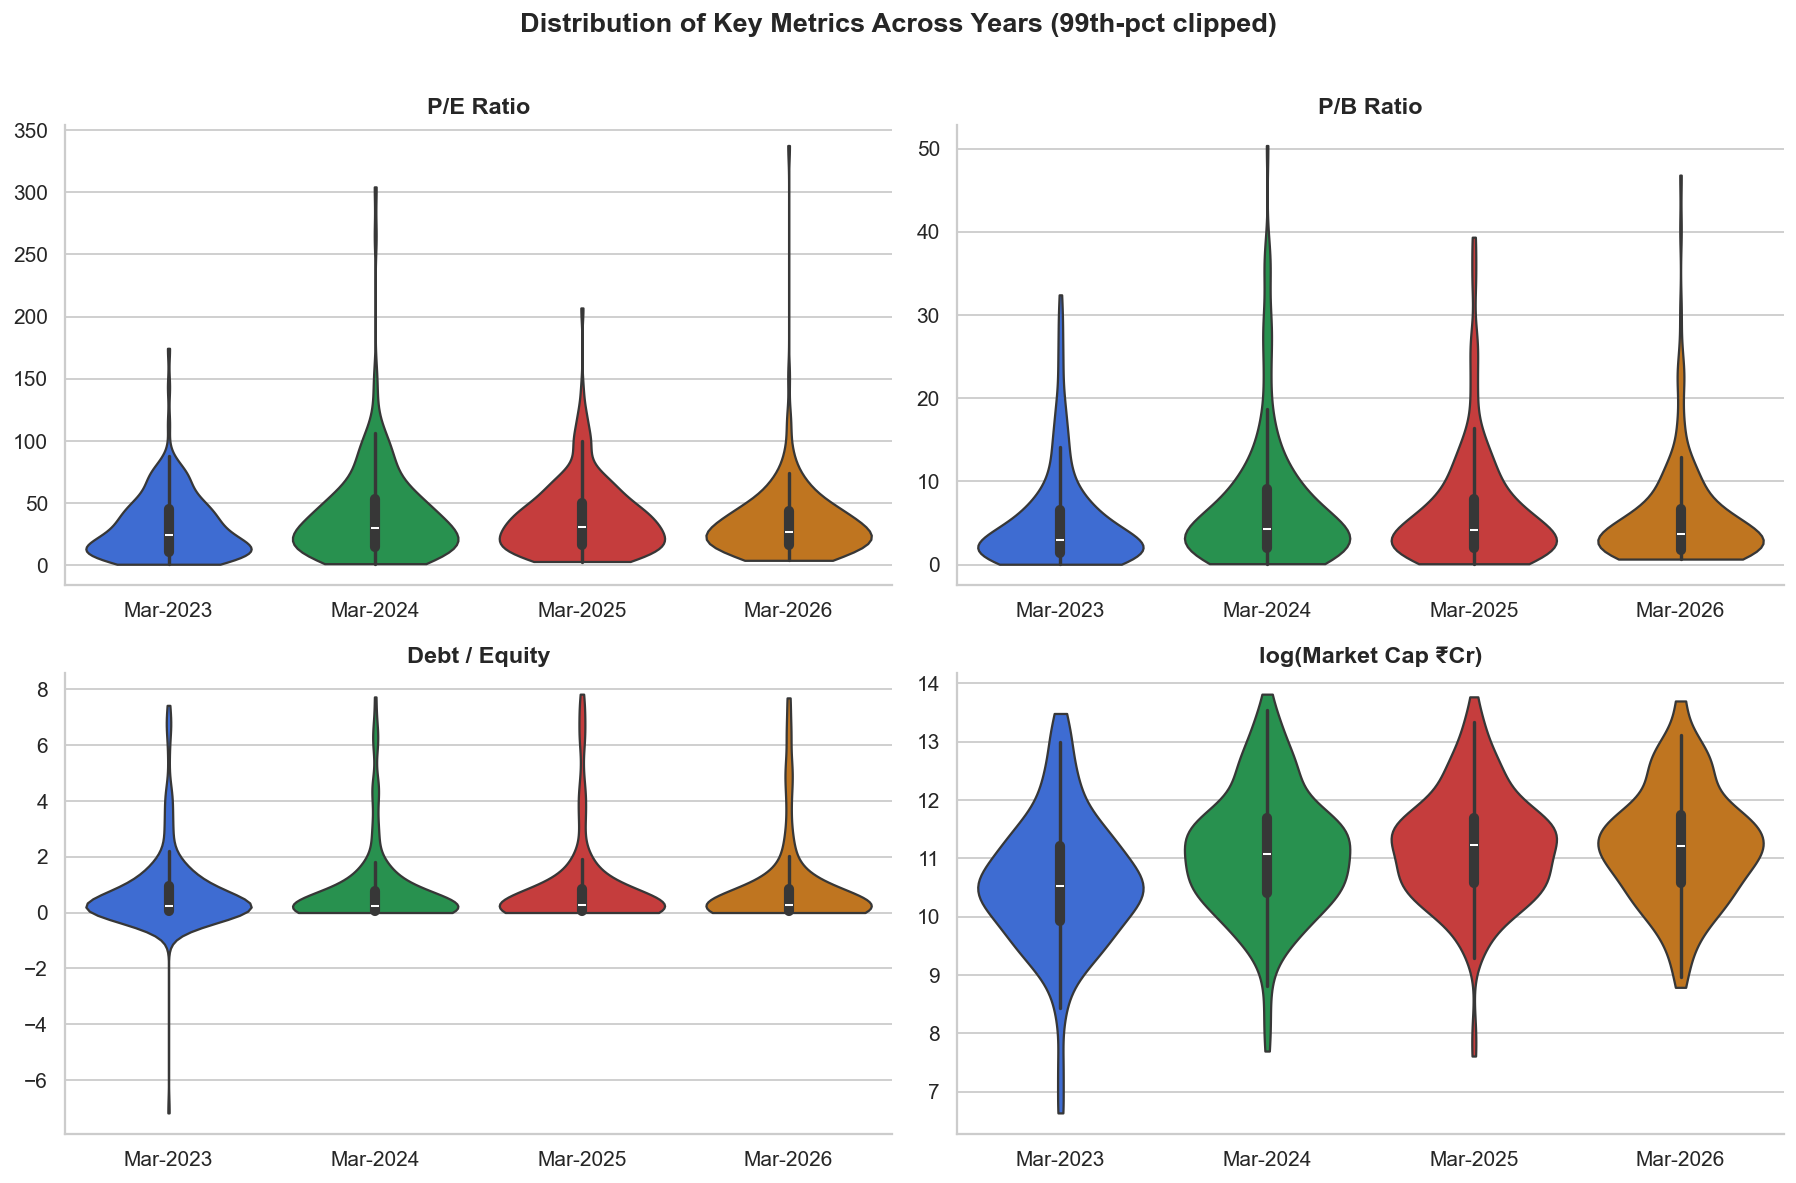

In [7]:
# ── Distribution violin plots across years ──────────────────────────────────
metrics = {'PE': 'P/E Ratio', 'PB': 'P/B Ratio',
           'DE': 'Debt / Equity', 'LogMCap': 'log(Market Cap ₹Cr)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
year_labels = dict(zip(YEARS, YLABELS))

for ax, (col, title) in zip(axes, metrics.items()):
    plot_df = panel.copy()
    plot_df['Year_Label'] = plot_df['Year'].map(year_labels)
    sub = plot_df.dropna(subset=[col])
    # Clip extreme outliers for plotting
    q99 = sub[col].quantile(0.99)
    sub = sub[sub[col] <= q99]
    sns.violinplot(data=sub, x='Year_Label', y=col, order=YLABELS,
                   palette=PALETTE[:4], inner='box', ax=ax, cut=0)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Distribution of Key Metrics Across Years (99th-pct clipped)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

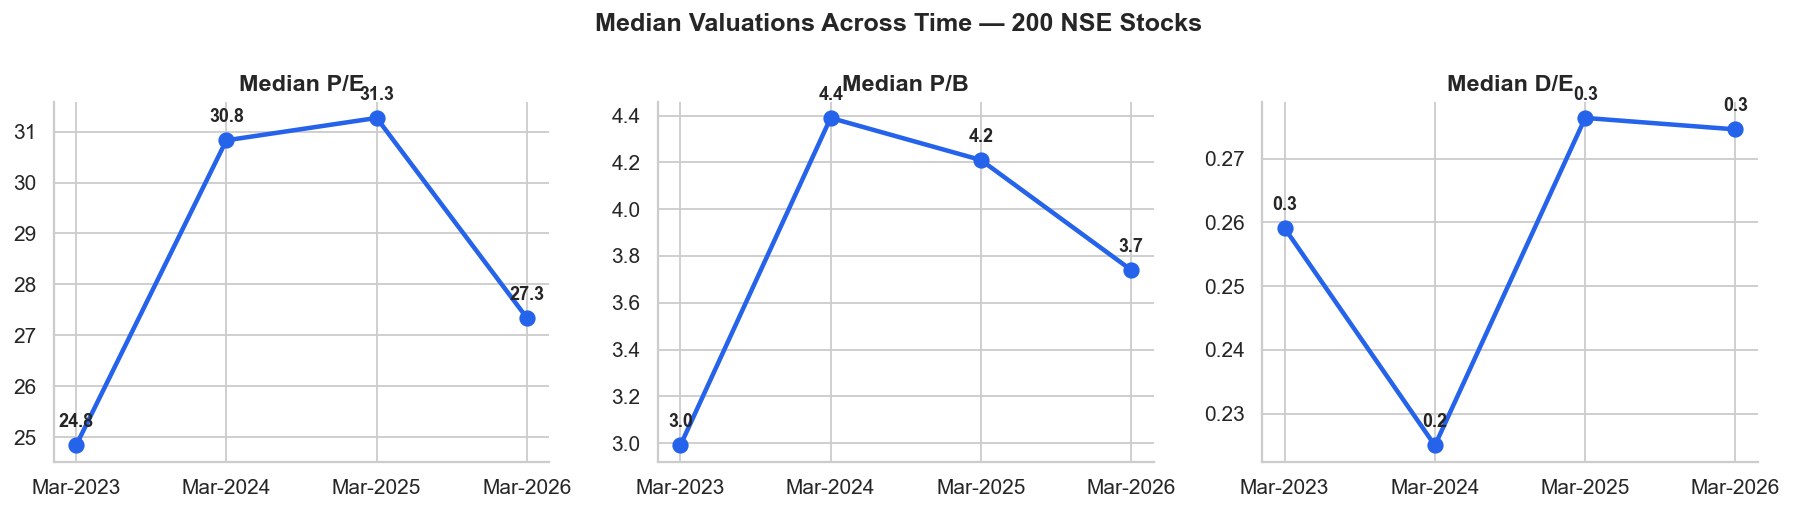

In [8]:
# ── Trend: median metrics over time ─────────────────────────────────────────
medians = panel.groupby('Year')[['PE','PB','DE']].median().reset_index()
medians['Year'] = medians['Year'].map(year_labels)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
specs = [('PE','Median P/E'),('PB','Median P/B'),('DE','Median D/E')]
for ax, (col, title) in zip(axes, specs):
    ax.plot(medians['Year'], medians[col], 'o-', lw=2.5, ms=8, color=PALETTE[0])
    for i, (x, y) in enumerate(zip(medians['Year'], medians[col])):
        ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('')
fig.suptitle('Median Valuations Across Time — 200 NSE Stocks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Cross-Sectional Correlation Analysis (Q6 & Q7)

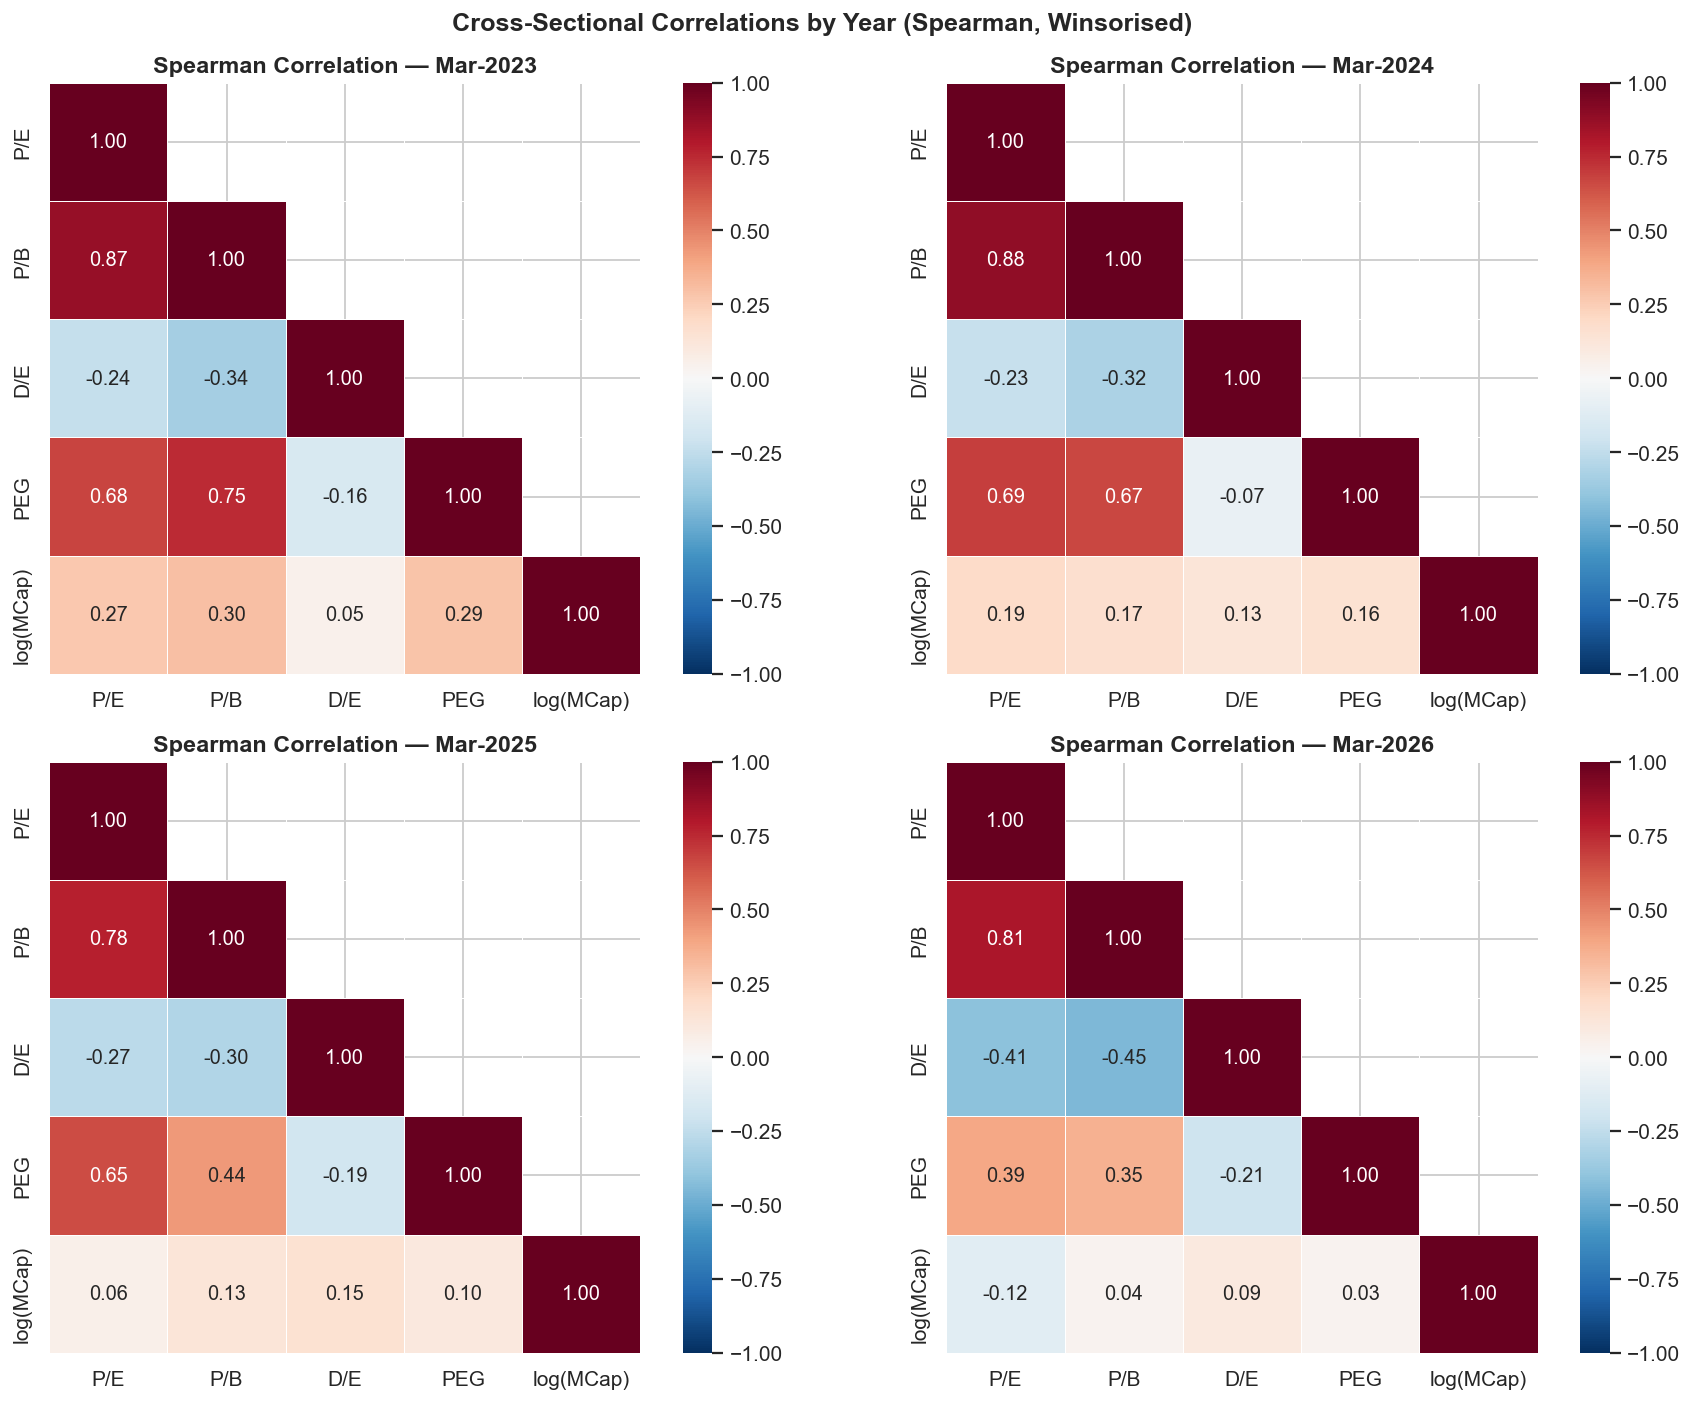

In [9]:
# ── Correlation heatmaps per year ────────────────────────────────────────────
corr_cols = ['PE', 'PB', 'DE', 'PEG', 'LogMCap']
corr_labels = ['P/E', 'P/B', 'D/E', 'PEG', 'log(MCap)']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
corr_store = {}

for ax, yr in zip(axes, YEARS):
    sub = panel[panel['Year'] == yr][corr_cols].dropna()
    # Winsorise at 2.5–97.5%
    sub = sub.apply(lambda c: c.clip(c.quantile(0.025), c.quantile(0.975)))
    corr = sub.corr(method='spearman')  # Spearman: robust to non-normality
    corr.index = corr_labels
    corr.columns = corr_labels
    corr_store[yr] = corr

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax,
                linewidths=0.5, square=True, annot_kws={'size': 11})
    ax.set_title(f'Spearman Correlation — {year_labels[yr]}')

fig.suptitle('Cross-Sectional Correlations by Year (Spearman, Winsorised)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

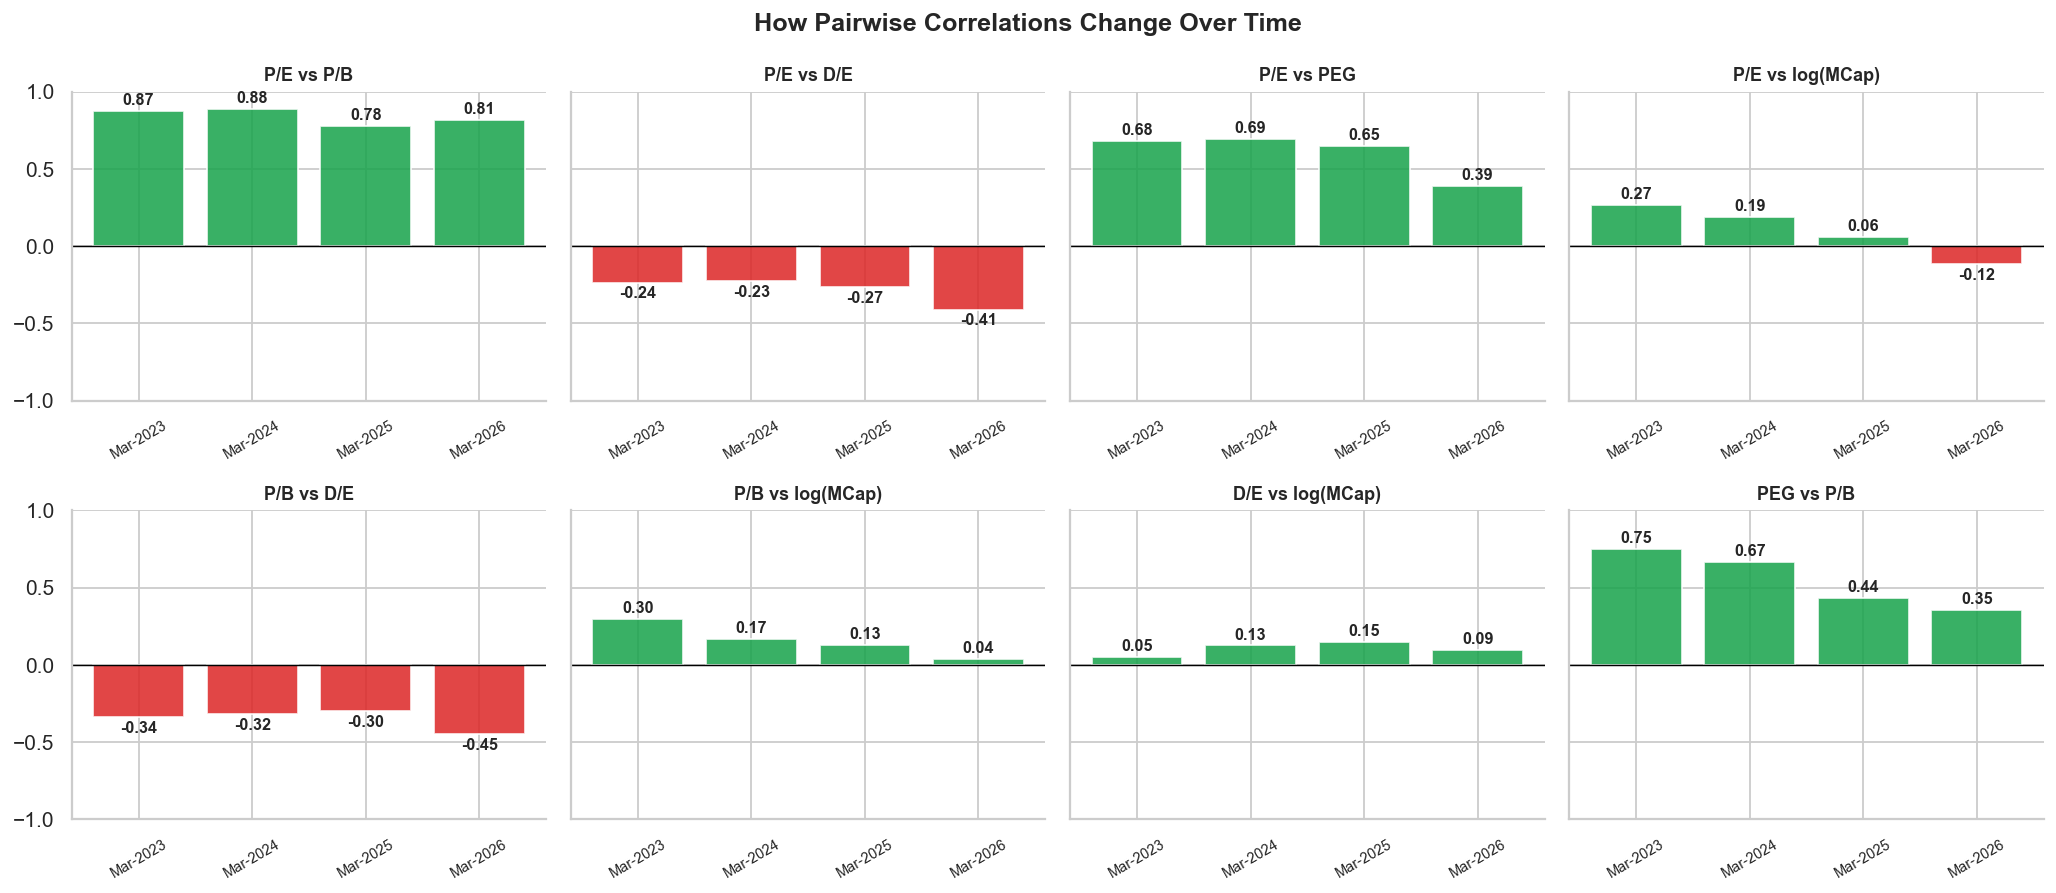

In [10]:
# ── How correlations change over time ───────────────────────────────────────
# Extract unique pairs and track over 4 years
pairs = [('P/E','P/B'),('P/E','D/E'),('P/E','PEG'),
         ('P/E','log(MCap)'),('P/B','D/E'),('P/B','log(MCap)'),
         ('D/E','log(MCap)'),('PEG','P/B')]

corr_ts = {}
for a, b in pairs:
    corr_ts[(a, b)] = [corr_store[yr].loc[a, b] for yr in YEARS]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()
for ax, (pair, vals) in zip(axes, corr_ts.items()):
    colors = ['#16A34A' if v >= 0 else '#DC2626' for v in vals]
    ax.bar(YLABELS, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{pair[0]} vs {pair[1]}', fontsize=10)
    ax.set_ylim(-1, 1)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v + (0.04 if v >= 0 else -0.10),
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('How Pairwise Correlations Change Over Time',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Optimal Number of Clusters (Q2)

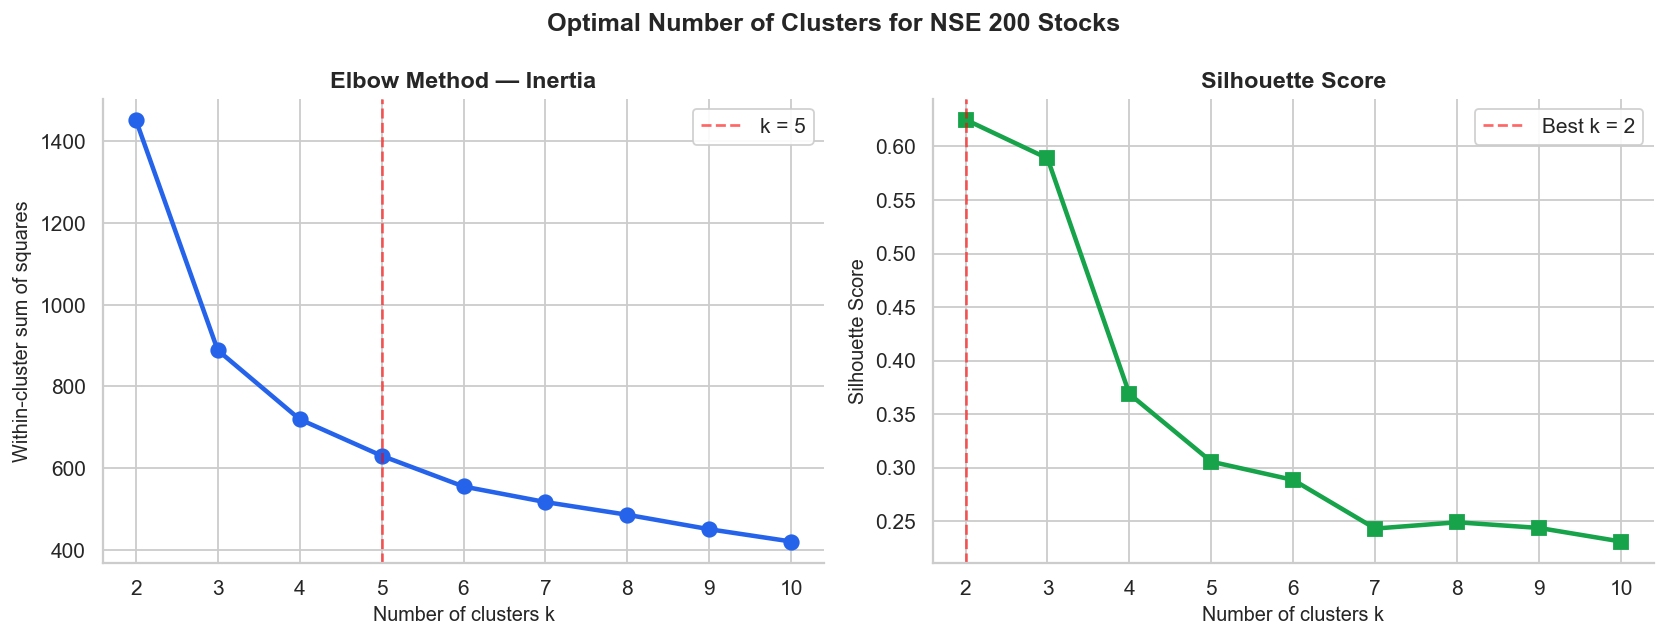


→ Selected k = 5 clusters (balanced interpretability + silhouette)


In [11]:
FEAT_COLS = ['PE', 'PB', 'DE', 'PEG', 'LogMCap']

def prepare_year_matrix(yr_panel):
    """Impute medians, winsorise, robust-scale features."""
    X = yr_panel[FEAT_COLS].copy()
    # Median impute
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    # Winsorise
    for i in range(X_imp.shape[1]):
        lo, hi = np.percentile(X_imp[:, i], [2.5, 97.5])
        X_imp[:, i] = np.clip(X_imp[:, i], lo, hi)
    # Robust scale
    scaler = RobustScaler()
    return scaler.fit_transform(X_imp)

# Use Mar-2026 panel to pick k
p2026 = panel[panel['Year'] == '2026-03-31'].reset_index(drop=True)
X2026 = prepare_year_matrix(p2026)

# Elbow + Silhouette
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labs = km.fit_predict(X2026)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X2026, labs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(ks), inertias, 'o-', color=PALETTE[0], lw=2.5, ms=8)
ax1.set_title('Elbow Method — Inertia')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Within-cluster sum of squares')
# Annotate elbow
ax1.axvline(5, ls='--', color='red', alpha=0.6, label='k = 5')
ax1.legend()

ax2.plot(list(ks), sils, 's-', color=PALETTE[1], lw=2.5, ms=8)
best_k = list(ks)[np.argmax(sils)]
ax2.axvline(best_k, ls='--', color='red', alpha=0.6, label=f'Best k = {best_k}')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

for ax in [ax1, ax2]:
    ax.set_xticks(list(ks))

fig.suptitle('Optimal Number of Clusters for NSE 200 Stocks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

N_CLUSTERS = 5
print(f'\n→ Selected k = {N_CLUSTERS} clusters (balanced interpretability + silhouette)')

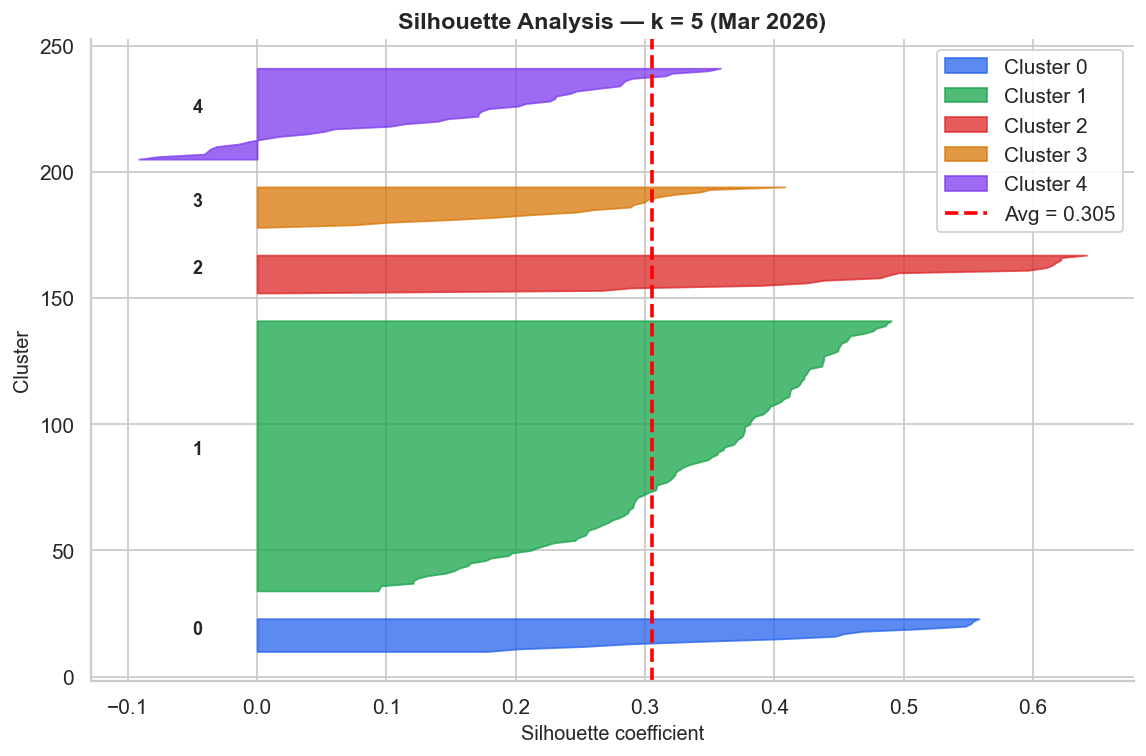

In [12]:
# ── Silhouette plot for k=5 ──────────────────────────────────────────────────
km5 = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=500)
labs_sil = km5.fit_predict(X2026)
sil_vals = silhouette_samples(X2026, labs_sil)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for i in range(N_CLUSTERS):
    ith_sil = np.sort(sil_vals[labs_sil == i])
    size = ith_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.75, color=PALETTE[i], label=f'Cluster {i}')
    ax.text(-0.05, y_lower + size / 2, str(i), fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X2026, labs_sil), color='red',
           linestyle='--', lw=2, label=f'Avg = {silhouette_score(X2026, labs_sil):.3f}')
ax.set_title('Silhouette Analysis — k = 5 (Mar 2026)', fontweight='bold')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [38]:
!pip install rpy2


   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   ---------- ----------------------------- 1/4 [rpy2-rinterface]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   -------------------- ------------------- 2/4 [rpy2-robjects]
   --------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [45]:
import pandas as pd

# 1. Create the DataFrame natively in Python
cluster_df = pd.DataFrame({
    "Cluster Name": ["Leveraged", "Large-Cap Stable", "Expensive", "Growth", "Value"],
    "Primary Signal": [
        "Highest median D/E",
        "Highest log(MCap), moderate PE",
        "Highest PE",
        "High PE + high PB + high MCap",
        "Lowest PE + lowest PB"
    ]
})

# 2. Replicate your R kable styling exactly using Pandas Styler
styled_table = (
    cluster_df.style
    .set_caption("Cluster Naming Convention")
    .set_properties(**{
        'text-align': 'left',
        'border': '1px solid #dee2e6',
        'padding': '8px'
    })
    # Style the headers (Row 0 equivalent)
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1e3a5f'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('border', '1px solid #dee2e6'),
            ('padding', '8px')
        ]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse')]}
    ], overwrite=False)
    # Row 1: Leveraged (Red theme)
    .set_properties(subset=pd.IndexSlice[0, :], **{'background-color': '#fde8e8', 'color': '#991b1b'})
    # Row 2: Large-Cap Stable (Purple theme)
    .set_properties(subset=pd.IndexSlice[1, :], **{'background-color': '#ede9fe', 'color': '#5b21b6'})
    # Row 3: Expensive (Amber theme)
    .set_properties(subset=pd.IndexSlice[2, :], **{'background-color': '#fef3c7', 'color': '#92400e'})
    # Row 4: Growth (Green theme)
    .set_properties(subset=pd.IndexSlice[3, :], **{'background-color': '#dcfce7', 'color': '#166534'})
    # Row 5: Value (Blue theme)
    .set_properties(subset=pd.IndexSlice[4, :], **{'background-color': '#dbeafe', 'color': '#1e40af'})
)

# 3. Display the table natively in Jupyter
styled_table

,Cluster Name,Primary Signal
0,Leveraged,Highest median D/E
1,Large-Cap Stable,"Highest log(MCap), moderate PE"
2,Expensive,Highest PE
3,Growth,High PE + high PB + high MCap
4,Value,Lowest PE + lowest PB


---
## 6. K-Means Clustering — All Four Years (Q1, Q3, Q4)

In [34]:
# ── Cluster stocks for every year ────────────────────────────────────────────
all_results = []

for yr in YEARS:
    sub = panel[panel['Year'] == yr].reset_index(drop=True)
    X = prepare_year_matrix(sub)
    km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=500)
    sub['RawCluster'] = km.fit_predict(X)

    # Compute cluster means on ORIGINAL (unscaled) features to name them
    sub_imp = sub[FEAT_COLS].copy()
    imp2 = SimpleImputer(strategy='median')
    sub_imp[:] = imp2.fit_transform(sub_imp)
    sub['PE_imp'] = sub_imp['PE']
    sub['PB_imp'] = sub_imp['PB']
    sub['DE_imp'] = sub_imp['DE']
    sub['LogMCap_imp'] = sub_imp['LogMCap']

    cmeans = sub.groupby('RawCluster')[['PE_imp','PB_imp','DE_imp','LogMCap_imp']].mean()

    # Assign semantic cluster names:
    # - Value:          low PE, low PB
    # - Growth:         high PE, high PB, high MCap
    # - Leveraged:      high DE
    # - Expensive:      highest PE
    # - Large-Cap Stable: highest MCap, moderate PE
    scores = cmeans.copy()
    scores['value_score']   = -scores['PE_imp'] - scores['PB_imp']
    scores['growth_score']  =  scores['PE_imp'] + scores['PB_imp'] + scores['LogMCap_imp']
    scores['lever_score']   =  scores['DE_imp']
    scores['expens_score']  =  scores['PE_imp']
    scores['largecap_score']=  scores['LogMCap_imp'] - 0.5*scores['PE_imp']

    # Greedy assignment to avoid duplicate names
    name_map = {}
    remaining = set(cmeans.index)
    assignments = [
        ('Leveraged',       'lever_score'),
        ('Large-Cap Stable','largecap_score'),
        ('Expensive',       'expens_score'),
        ('Growth',          'growth_score'),
        ('Value',           'value_score'),
    ]
    for name, col in assignments:
        if not remaining:
            break
        best = scores.loc[list(remaining), col].idxmax()
        name_map[best] = name
        remaining.discard(best)
    # Any left-over
    fallback_names = ['Extra-A','Extra-B','Extra-C']
    for i, rc in enumerate(remaining):
        name_map[rc] = fallback_names[i]

    sub['Cluster'] = sub['RawCluster'].map(name_map)
    all_results.append(sub)

panel_clustered = pd.concat(all_results, ignore_index=True)
print('Cluster assignment done. Sample:')
panel_clustered[['Ticker','Company','Year','Cluster']].head(8)

Cluster assignment done. Sample:


,Ticker,Company,Year,Cluster
0,3MINDIA,3M India Ltd.,2023-03-31,Growth
1,ABB,ABB India Ltd.,2023-03-31,Growth
2,ACC,ACC Ltd.,2023-03-31,Large-Cap Stable
3,ADANIENT,Adani Enterprises Ltd.,2023-03-31,Growth
4,ADANIGREEN,Adani Green Energy Ltd.,2023-03-31,Expensive
5,ADANIPORTS,Adani Ports & SEZ Ltd.,2023-03-31,Large-Cap Stable
6,ADANIPOWER,Adani Power Ltd.,2023-03-31,Large-Cap Stable
7,ATGL,Adani Total Gas Ltd.,2023-03-31,Value


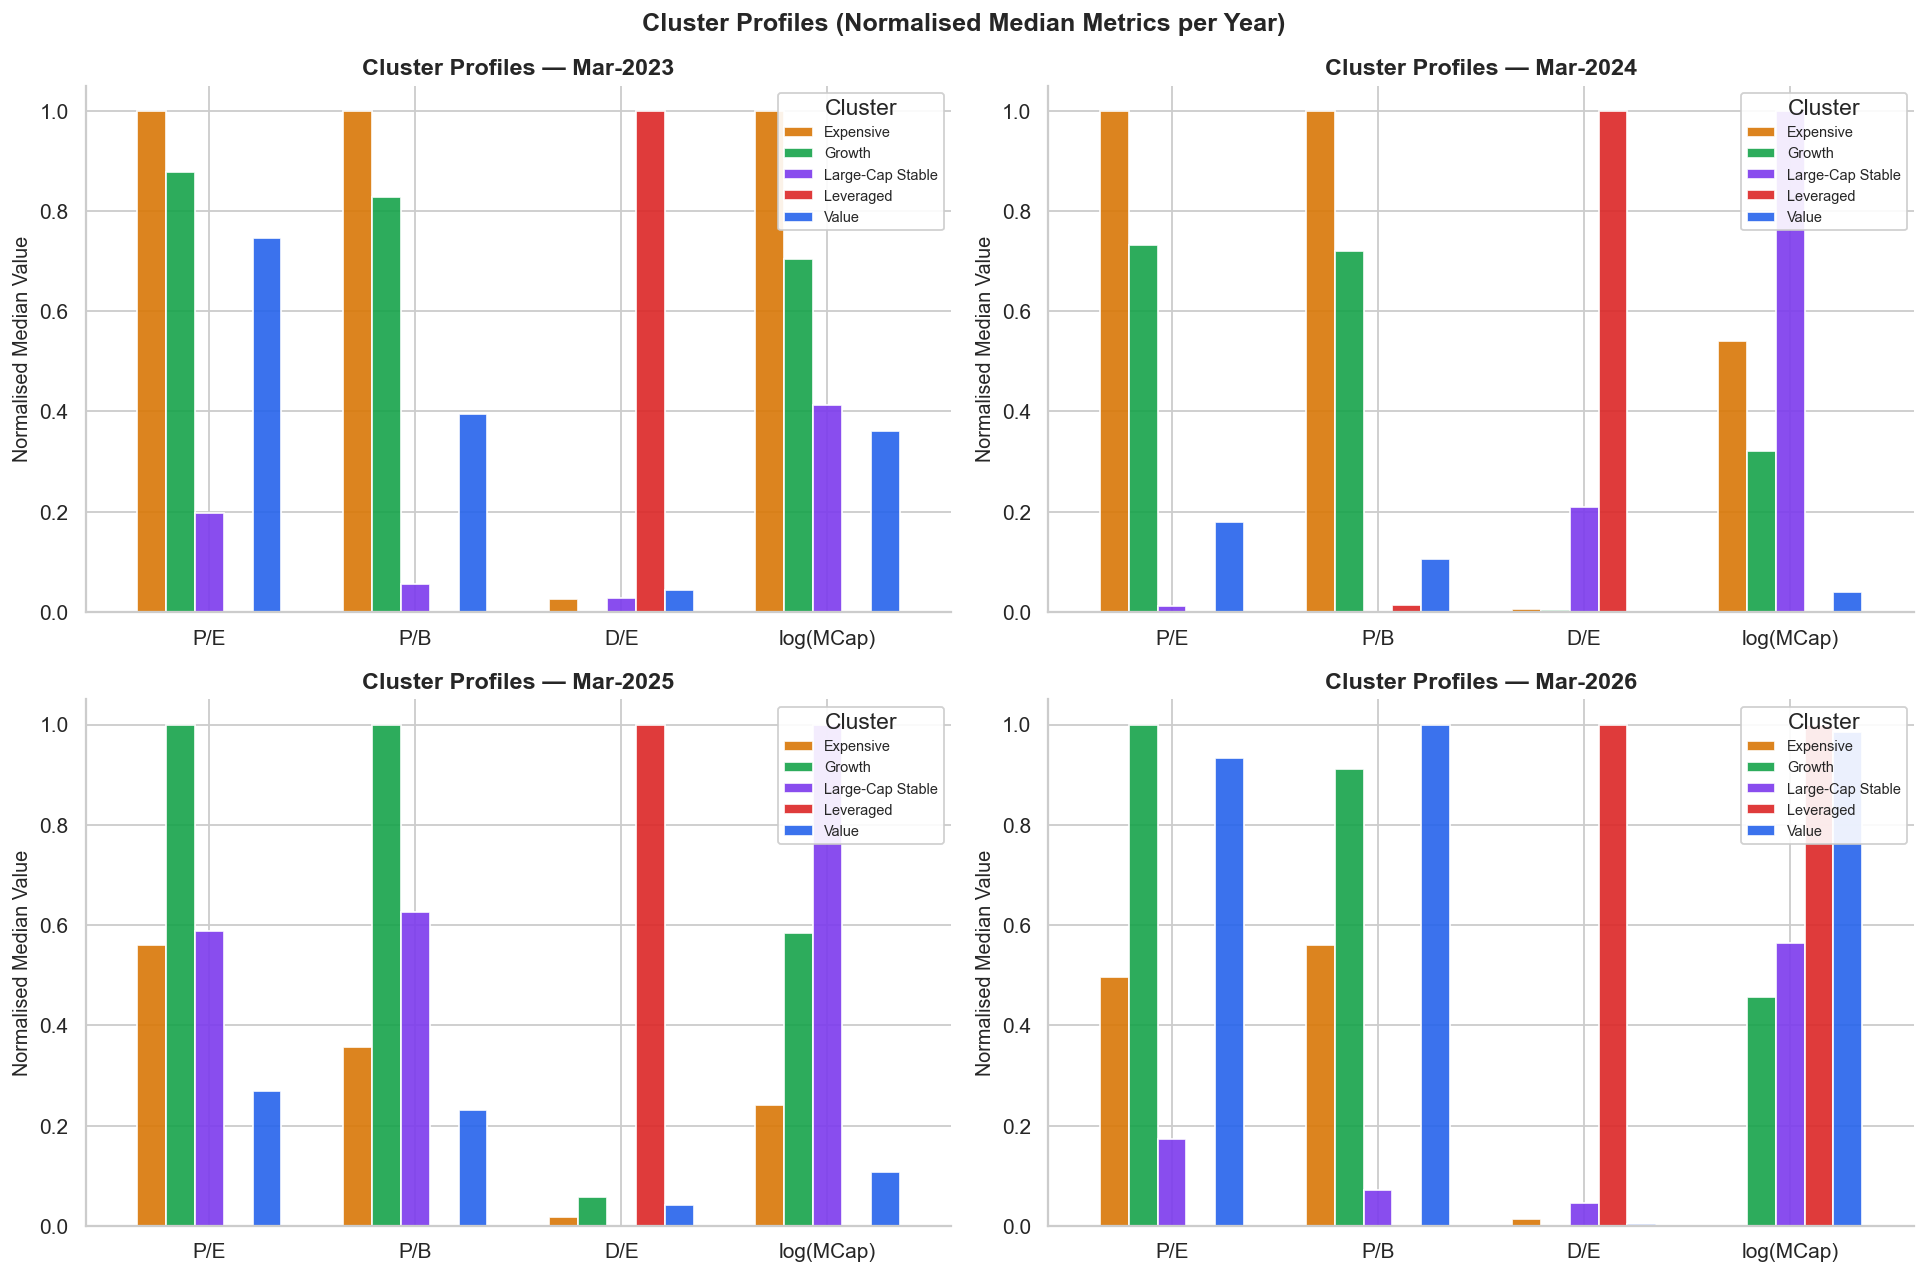

In [14]:
# ── Cluster profiles — radar / bar charts ────────────────────────────────────
CLUSTER_COLORS = {
    'Value':           '#2563EB',
    'Growth':          '#16A34A',
    'Leveraged':       '#DC2626',
    'Expensive':       '#D97706',
    'Large-Cap Stable':'#7C3AED',
    'Extra-A':         '#0891B2',
    'Extra-B':         '#65A30D',
    'Extra-C':         '#EA580C',
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, yr in zip(axes, YEARS):
    sub = panel_clustered[panel_clustered['Year'] == yr]
    profile = sub.groupby('Cluster')[['PE_imp','PB_imp','DE_imp','LogMCap_imp']].median()
    profile.columns = ['P/E','P/B','D/E','log(MCap)']
    # Normalise each metric to 0–1 for bar comparison
    norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
    norm.T.plot(kind='bar', ax=ax, width=0.7,
                color=[CLUSTER_COLORS.get(c, 'grey') for c in norm.index],
                edgecolor='white', alpha=0.9)
    ax.set_title(f'Cluster Profiles — {year_labels[yr]}')
    ax.set_xlabel('')
    ax.set_ylabel('Normalised Median Value')
    ax.tick_params(axis='x', labelrotation=0)
    ax.legend(title='Cluster', fontsize=8, loc='upper right')

fig.suptitle('Cluster Profiles (Normalised Median Metrics per Year)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

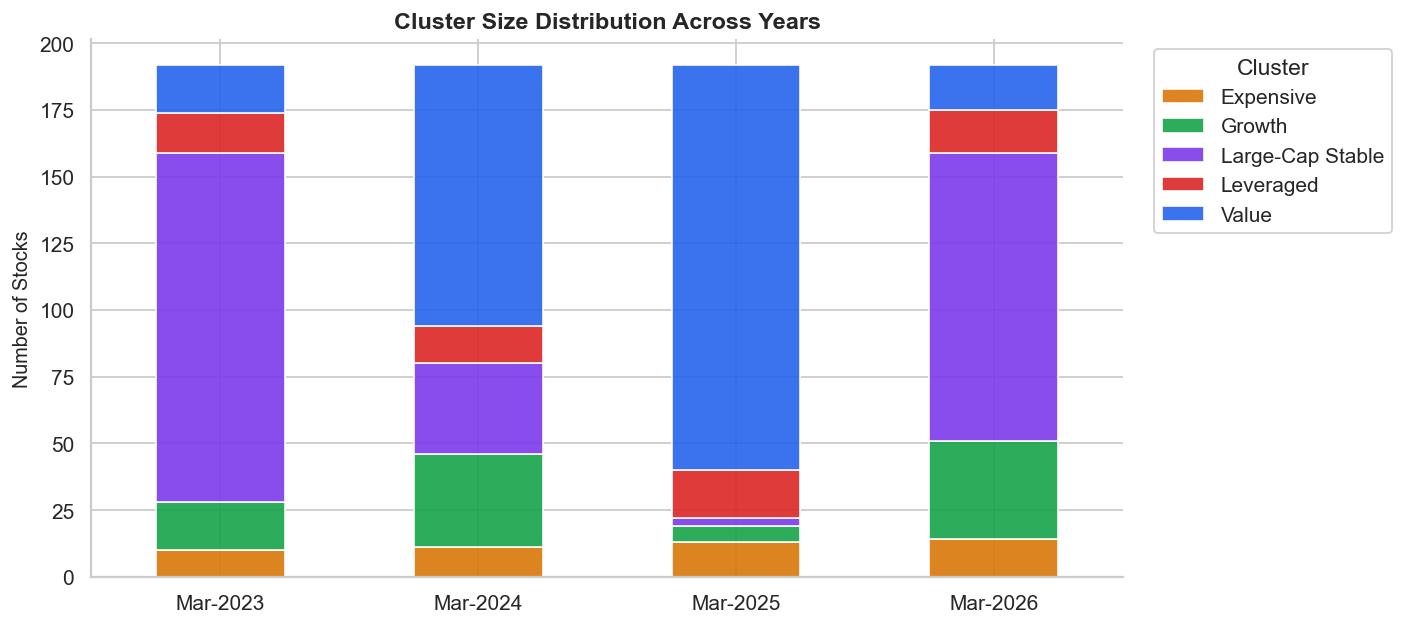


Cluster sizes per year:
Cluster   Expensive  Growth  Large-Cap Stable  Leveraged  Value
Mar-2023         10      18               131         15     18
Mar-2024         11      35                34         14     98
Mar-2025         13       6                 3         18    152
Mar-2026         14      37               108         16     17


In [15]:
# ── Cluster size evolution ──────────────────────────────────────────────────
sizes = panel_clustered.groupby(['Year','Cluster']).size().unstack(fill_value=0)
sizes.index = [year_labels[y] for y in sizes.index]

fig, ax = plt.subplots(figsize=(11, 5))
sizes.plot(kind='bar', stacked=True, ax=ax,
           color=[CLUSTER_COLORS.get(c, 'grey') for c in sizes.columns],
           edgecolor='white', alpha=0.9)
ax.set_title('Cluster Size Distribution Across Years', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Stocks')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', labelrotation=0)
plt.tight_layout()
plt.show()

print('\nCluster sizes per year:')
print(sizes)

In [16]:
# ── Raw cluster statistics per year ─────────────────────────────────────────
for yr in YEARS:
    sub = panel_clustered[panel_clustered['Year'] == yr]
    print(f"\n{'='*60}")
    print(f'  {year_labels[yr]}  — Cluster Median Statistics')
    print(f"{'='*60}")
    stats_tbl = sub.groupby('Cluster')[['PE_imp','PB_imp','DE_imp','LogMCap_imp']].agg(
        ['median','count']).round(2)
    print(stats_tbl)


  Mar-2023  — Cluster Median Statistics
                 PE_imp       PB_imp       DE_imp       LogMCap_imp      
                 median count median count median count      median count
Cluster                                                                  
Expensive         69.72    10  17.92    10   0.21    10       10.90    10
Growth            62.14    18  15.09    18   0.10    18       10.72    18
Large-Cap Stable  19.96   131   2.41   131   0.22   131       10.53   131
Leveraged          7.74    15   1.48    15   4.45    15       10.27    15
Value             53.91    18   7.98    18   0.29    18       10.50    18

  Mar-2024  — Cluster Median Statistics
                 PE_imp       PB_imp       DE_imp       LogMCap_imp      
                 median count median count median count      median count
Cluster                                                                  
Expensive         82.77    11  18.68    11   0.15    11       11.38    11
Growth            65.13    35 

---
## 7. PCA Visualisation of Clusters (Q1)

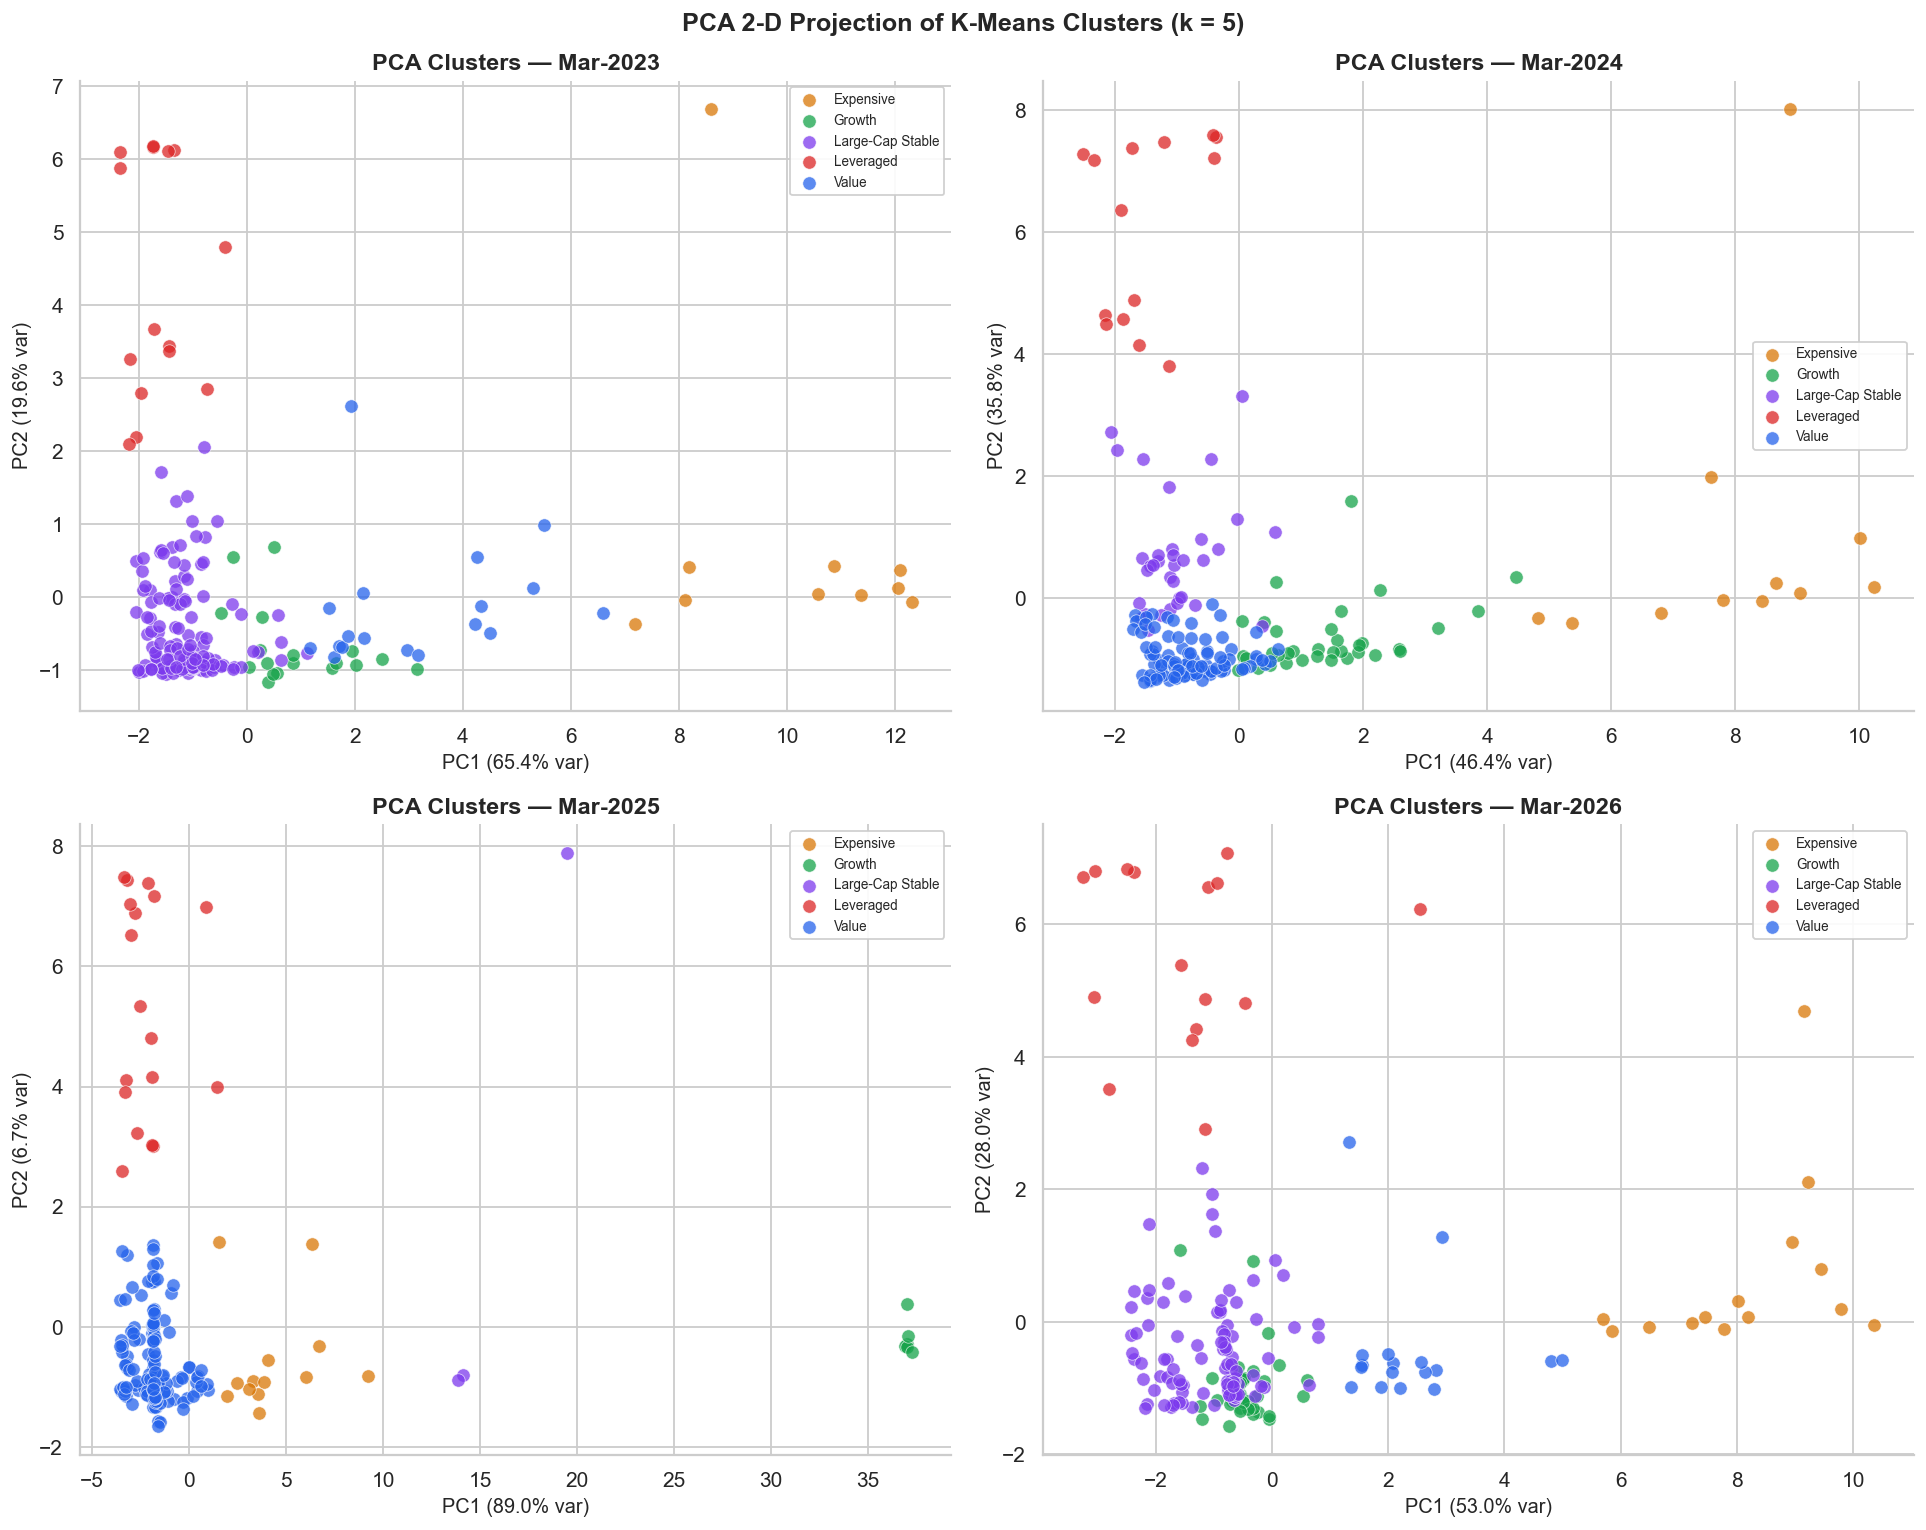

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, yr in zip(axes, YEARS):
    sub = panel_clustered[panel_clustered['Year'] == yr].reset_index(drop=True)
    X = prepare_year_matrix(sub)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    sub['PC1'] = coords[:, 0]
    sub['PC2'] = coords[:, 1]

    for cl, grp in sub.groupby('Cluster'):
        ax.scatter(grp['PC1'], grp['PC2'],
                   label=cl, s=55, alpha=0.75,
                   color=CLUSTER_COLORS.get(cl, 'grey'),
                   edgecolors='white', linewidths=0.4)

    ax.set_title(f'PCA Clusters — {year_labels[yr]}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.legend(fontsize=7.5, loc='best')

fig.suptitle('PCA 2-D Projection of K-Means Clusters (k = 5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Stock Migration Between Clusters (Q4 & Q5)

In [18]:
# ── Build a wide table: one row per stock, cluster label per year ────────────
wide = panel_clustered[['Ticker','Company','Year','Cluster']].pivot(
    index=['Ticker','Company'], columns='Year', values='Cluster').reset_index()
wide.columns.name = None

# Stable stocks = same cluster all 4 years
wide['Stable'] = wide[YEARS[0]] == wide[YEARS[1]]
for yr in YEARS[2:]:
    wide['Stable'] = wide['Stable'] & (wide[YEARS[0]] == wide[yr])

print(f'\nStocks stable across all 4 years: {wide["Stable"].sum()}/{len(wide)}')
print('\nStable stocks sample:')
print(wide[wide['Stable']].head(10)[['Ticker','Company'] + YEARS])


Stocks stable across all 4 years: 11/192

Stable stocks sample:
         Ticker                                 Company 2023-03-31 2024-03-31  \
2     ABCAPITAL               Aditya Birla Capital Ltd.  Leveraged  Leveraged   
14     ASHOKLEY                      Ashok Leyland Ltd.  Leveraged  Leveraged   
22   BAJAJFINSV                      Bajaj Finserv Ltd.  Leveraged  Leveraged   
42     CHOLAFIN     Cholamandalam Investment & Fin. Co.  Leveraged  Leveraged   
84        HUDCO              Housing & Urban Dev. Corp.  Leveraged  Leveraged   
91         IIFL                       IIFL Finance Ltd.  Leveraged  Leveraged   
103       IREDA     Indian Renewable Energy Dev. Agency  Leveraged  Leveraged   
116   LICHSGFIN                LIC Housing Finance Ltd.  Leveraged  Leveraged   
123      M&MFIN  Mahindra & Mahindra Financial Services  Leveraged  Leveraged   
151         PFC          Power Finance Corporation Ltd.  Leveraged  Leveraged   

    2025-03-31 2026-03-31  
2    Leveraged 

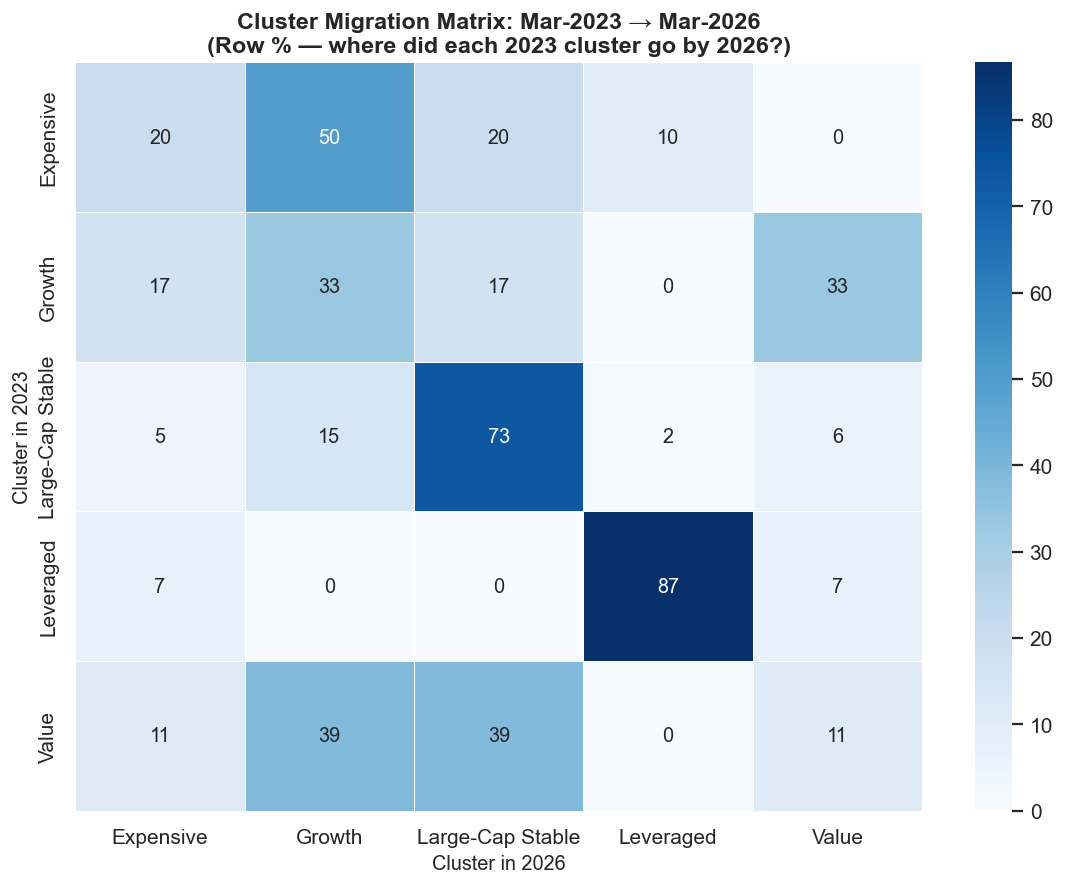

In [19]:
# ── Transition matrix: 2023 → 2026 ──────────────────────────────────────────
trans = pd.crosstab(
    wide['2023-03-31'].fillna('Unknown'),
    wide['2026-03-31'].fillna('Unknown'),
    margins=False
)

fig, ax = plt.subplots(figsize=(9, 7))
# Normalise rows
trans_pct = trans.div(trans.sum(axis=1), axis=0) * 100
sns.heatmap(trans_pct, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Cluster Migration Matrix: Mar-2023 → Mar-2026\n(Row % — where did each 2023 cluster go by 2026?)',
             fontweight='bold')
ax.set_xlabel('Cluster in 2026')
ax.set_ylabel('Cluster in 2023')
plt.tight_layout()
plt.show()

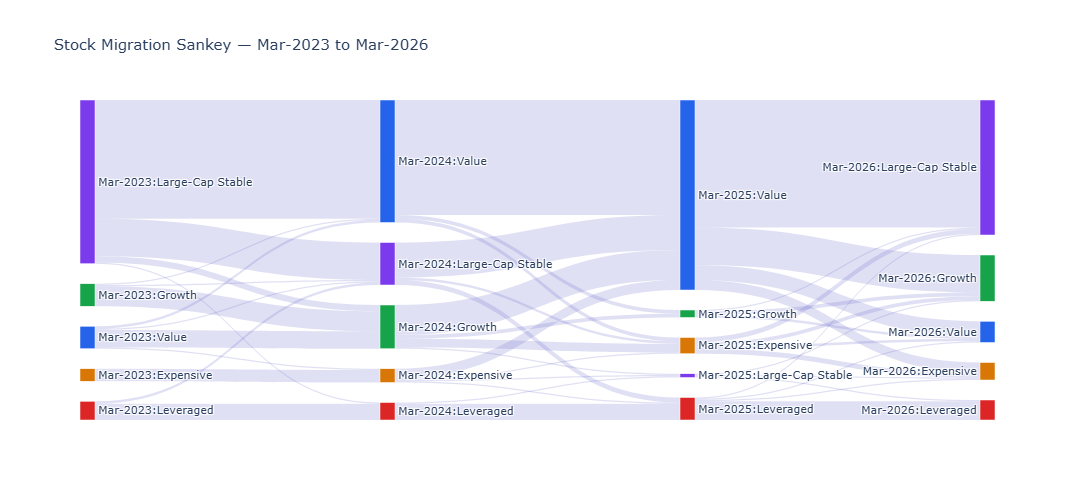

In [21]:
# ── Sankey-style alluvial using Plotly ──────────────────────────────────────
all_labels = []
for i, yr in enumerate(YEARS):
    for cl in sorted(panel_clustered['Cluster'].unique()):
        all_labels.append(f'{year_labels[yr]}:{cl}')

label_idx = {l: i for i, l in enumerate(all_labels)}
sources, targets, values = [], [], []

for y1, y2 in zip(YEARS[:-1], YEARS[1:]):
    pair = wide[[y1, y2]].dropna()
    for (c1, c2), cnt in pair.groupby([y1, y2]).size().items():
        sources.append(label_idx[f'{year_labels[y1]}:{c1}'])
        targets.append(label_idx[f'{year_labels[y2]}:{c2}'])
        values.append(cnt)

node_colors = []
for lbl in all_labels:
    cl = lbl.split(':')[1]
    node_colors.append(CLUSTER_COLORS.get(cl, '#999999'))

fig_sankey = go.Figure(go.Sankey(
    node=dict(pad=20, thickness=15, label=all_labels,
              color=node_colors, line=dict(color='white', width=0.5)),
    link=dict(source=sources, target=targets, value=values,
              color='rgba(100,100,200,0.2)')
))
fig_sankey.update_layout(
    title_text='Stock Migration Sankey — Mar-2023 to Mar-2026',
    font_size=11,
    height=500
)
fig_sankey.show()

---
## 9. Industry Analysis Within Clusters (Q8 & Q9)

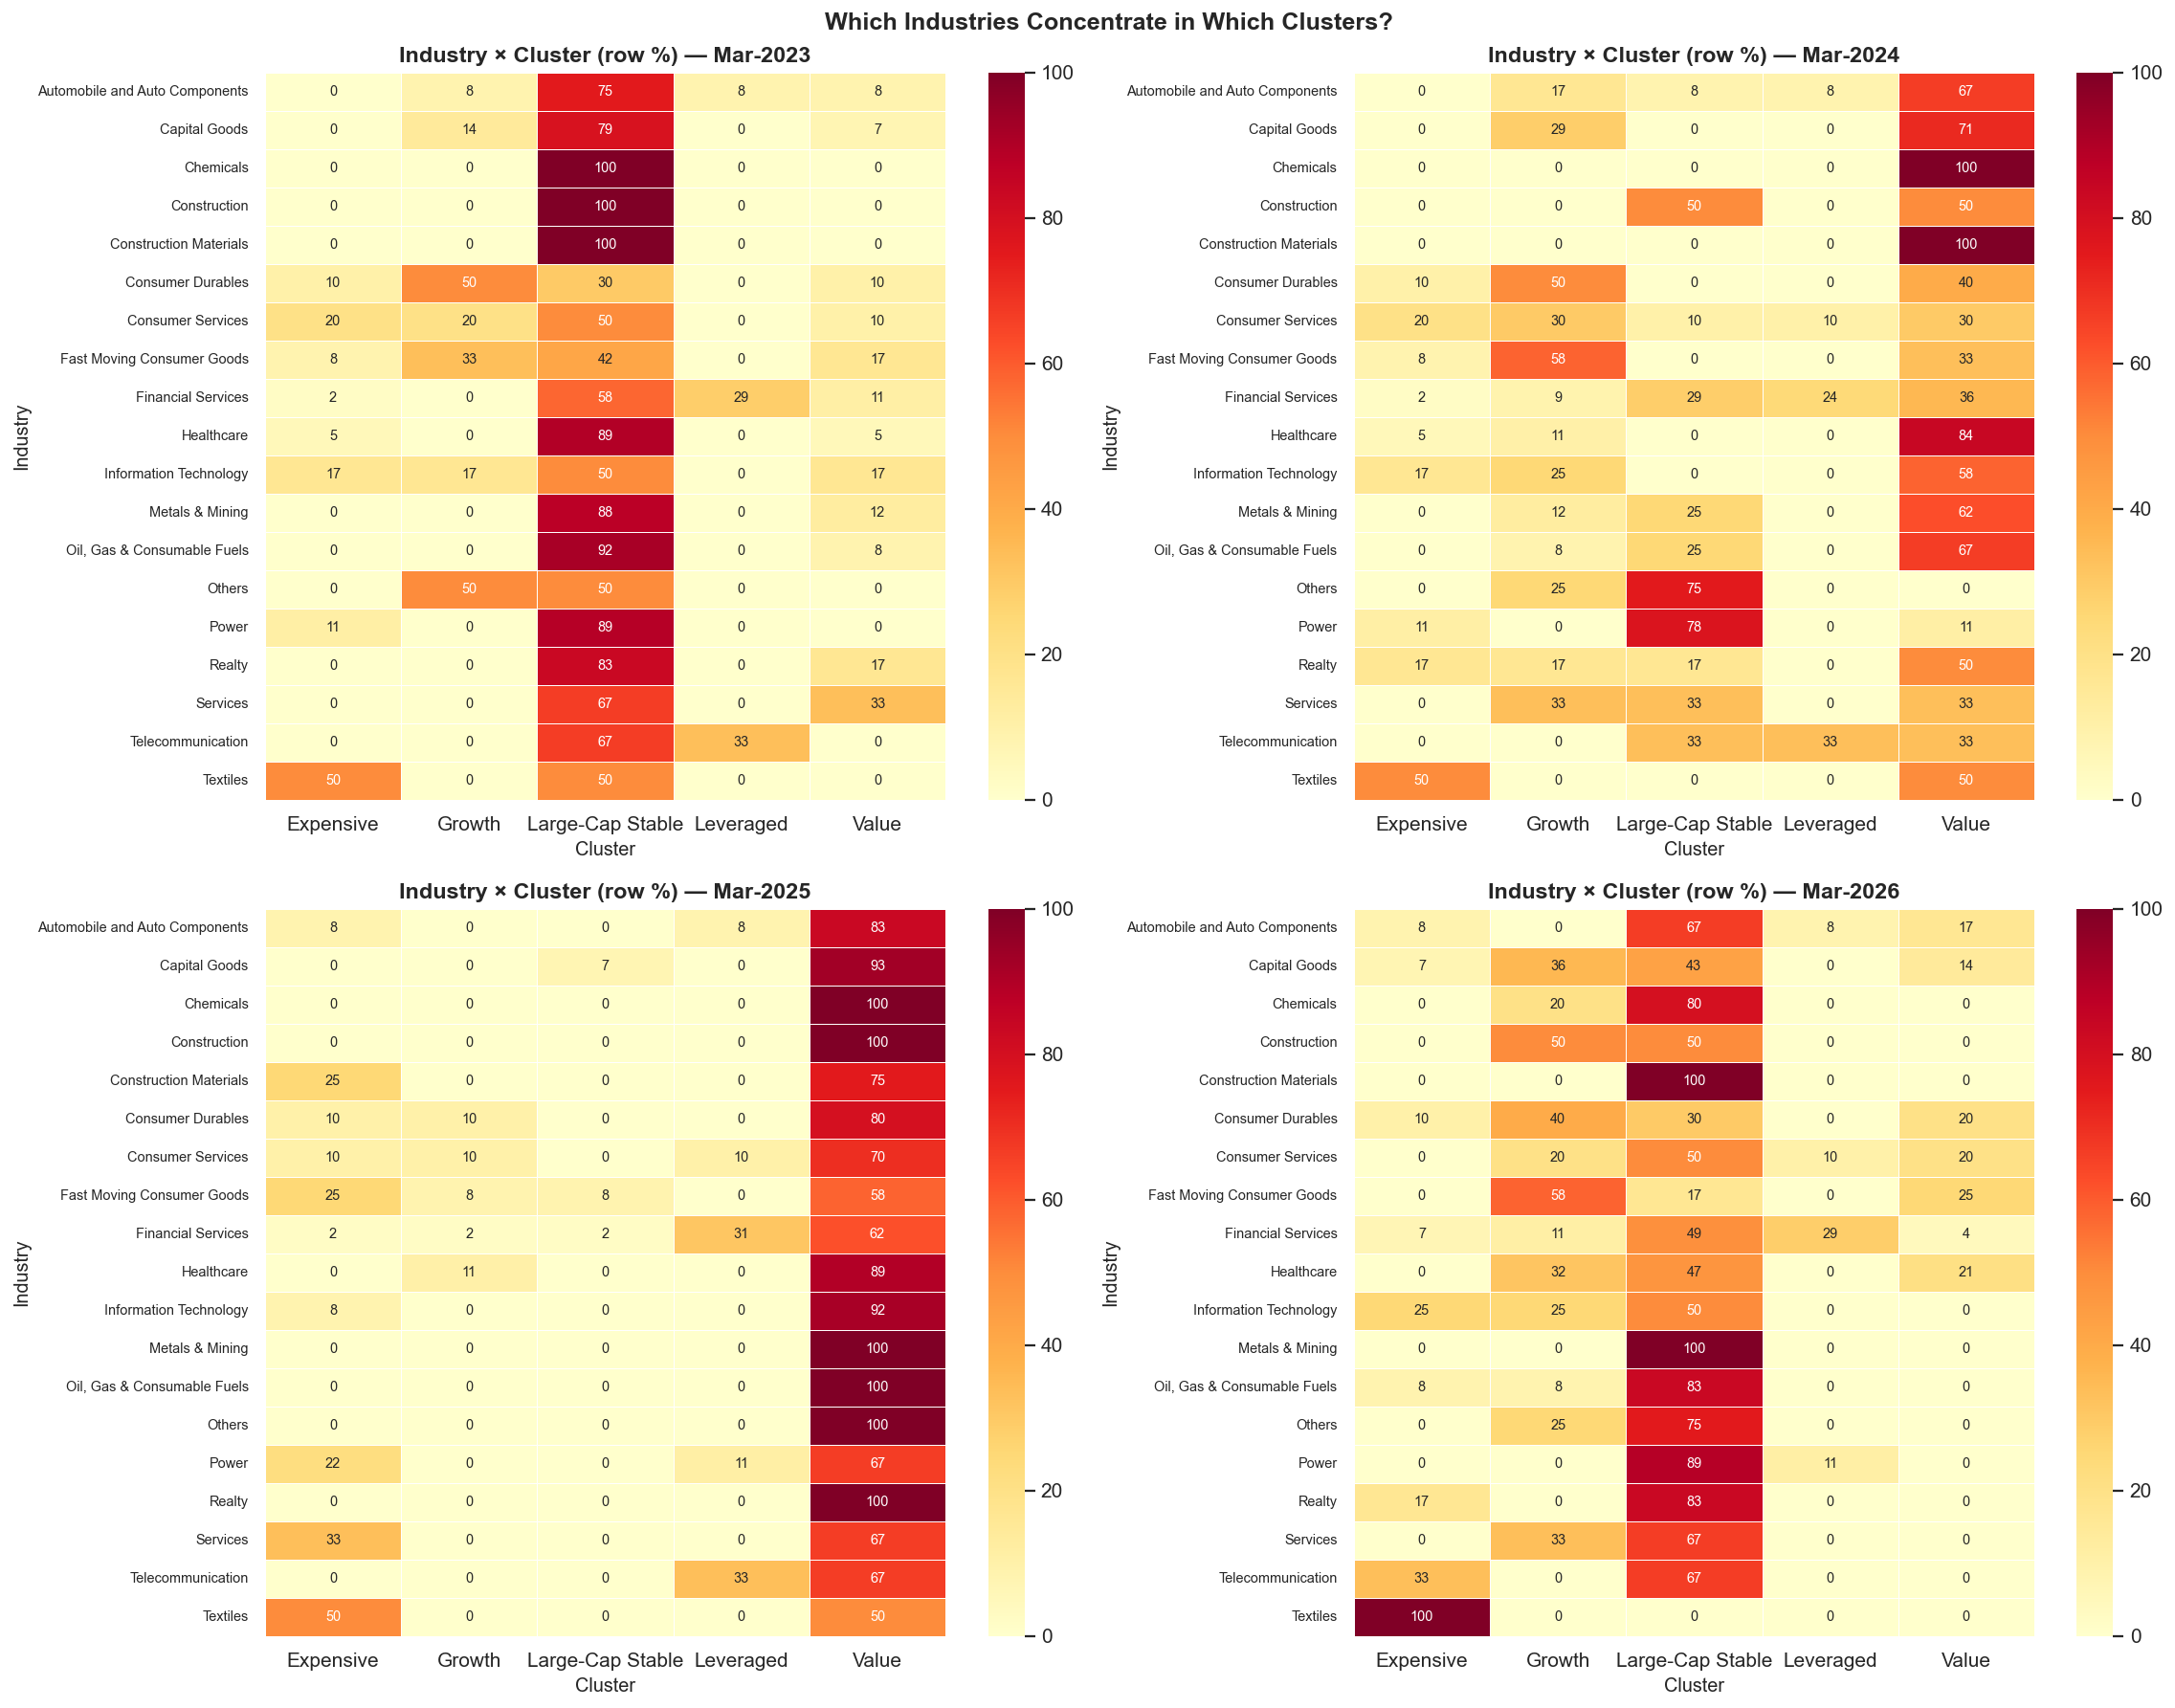

In [22]:
# ── Industry × Cluster heatmap for each year ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, yr in zip(axes, YEARS):
    sub = panel_clustered[panel_clustered['Year'] == yr]
    ct = pd.crosstab(sub['Industry / Sector'], sub['Cluster'])
    # Percentage within industry
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title(f'Industry × Cluster (row %) — {year_labels[yr]}')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Industry')
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Which Industries Concentrate in Which Clusters?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

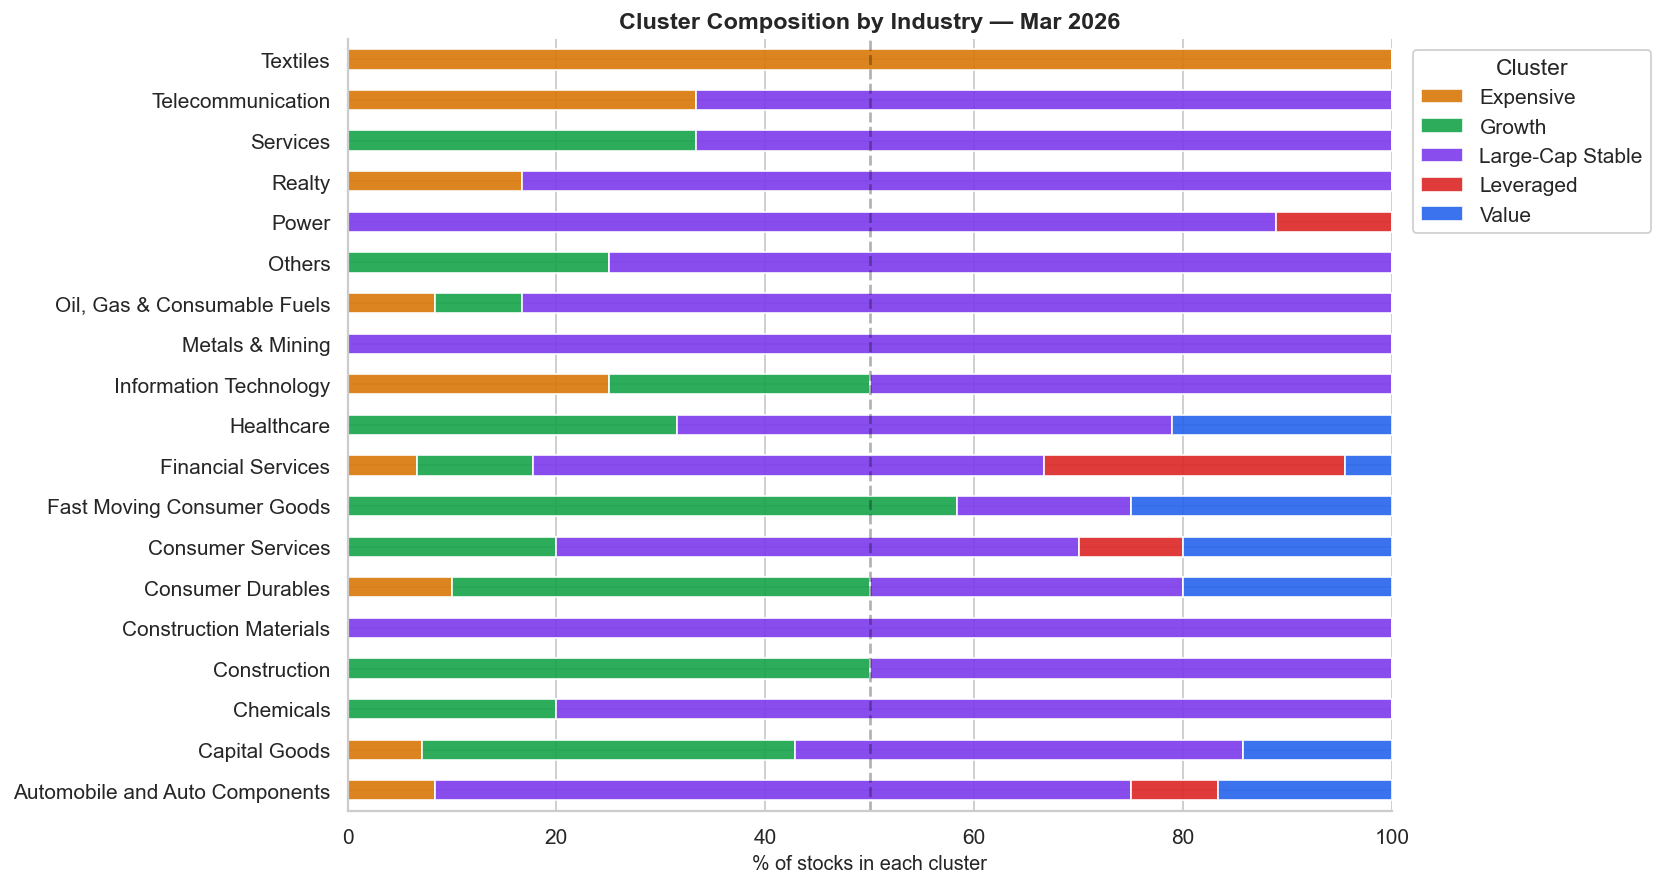

In [23]:
# ── Stacked bar: cluster composition per industry (2026) ─────────────────────
yr = '2026-03-31'
sub = panel_clustered[panel_clustered['Year'] == yr]
ct = pd.crosstab(sub['Industry / Sector'], sub['Cluster'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))
ct_pct.plot(kind='barh', stacked=True, ax=ax,
            color=[CLUSTER_COLORS.get(c, 'grey') for c in ct_pct.columns],
            edgecolor='white', alpha=0.9)
ax.set_title('Cluster Composition by Industry — Mar 2026', fontweight='bold')
ax.set_xlabel('% of stocks in each cluster')
ax.set_ylabel('')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axvline(50, ls='--', color='black', alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ── Chi-square test: does industry explain clustering? ───────────────────────
from scipy.stats import chi2_contingency

print('Chi-square test — Industry vs Cluster')
print('-' * 50)
for yr in YEARS:
    sub = panel_clustered[panel_clustered['Year'] == yr]
    ct = pd.crosstab(sub['Industry / Sector'], sub['Cluster'])
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.sum().sum()
    cramersV = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f'{year_labels[yr]}: χ²={chi2:.1f}, p={p:.4f}, '
          f'Cramér\'s V={cramersV:.3f} ({"strong" if cramersV>0.3 else "moderate" if cramersV>0.1 else "weak"} association)')

Chi-square test — Industry vs Cluster
--------------------------------------------------
Mar-2023: χ²=122.2, p=0.0002, Cramér's V=0.399 (strong association)
Mar-2024: χ²=142.9, p=0.0000, Cramér's V=0.431 (strong association)
Mar-2025: χ²=86.2, p=0.1217, Cramér's V=0.335 (strong association)
Mar-2026: χ²=132.3, p=0.0000, Cramér's V=0.415 (strong association)


---
## 10. Hierarchical Clustering Dendrogram

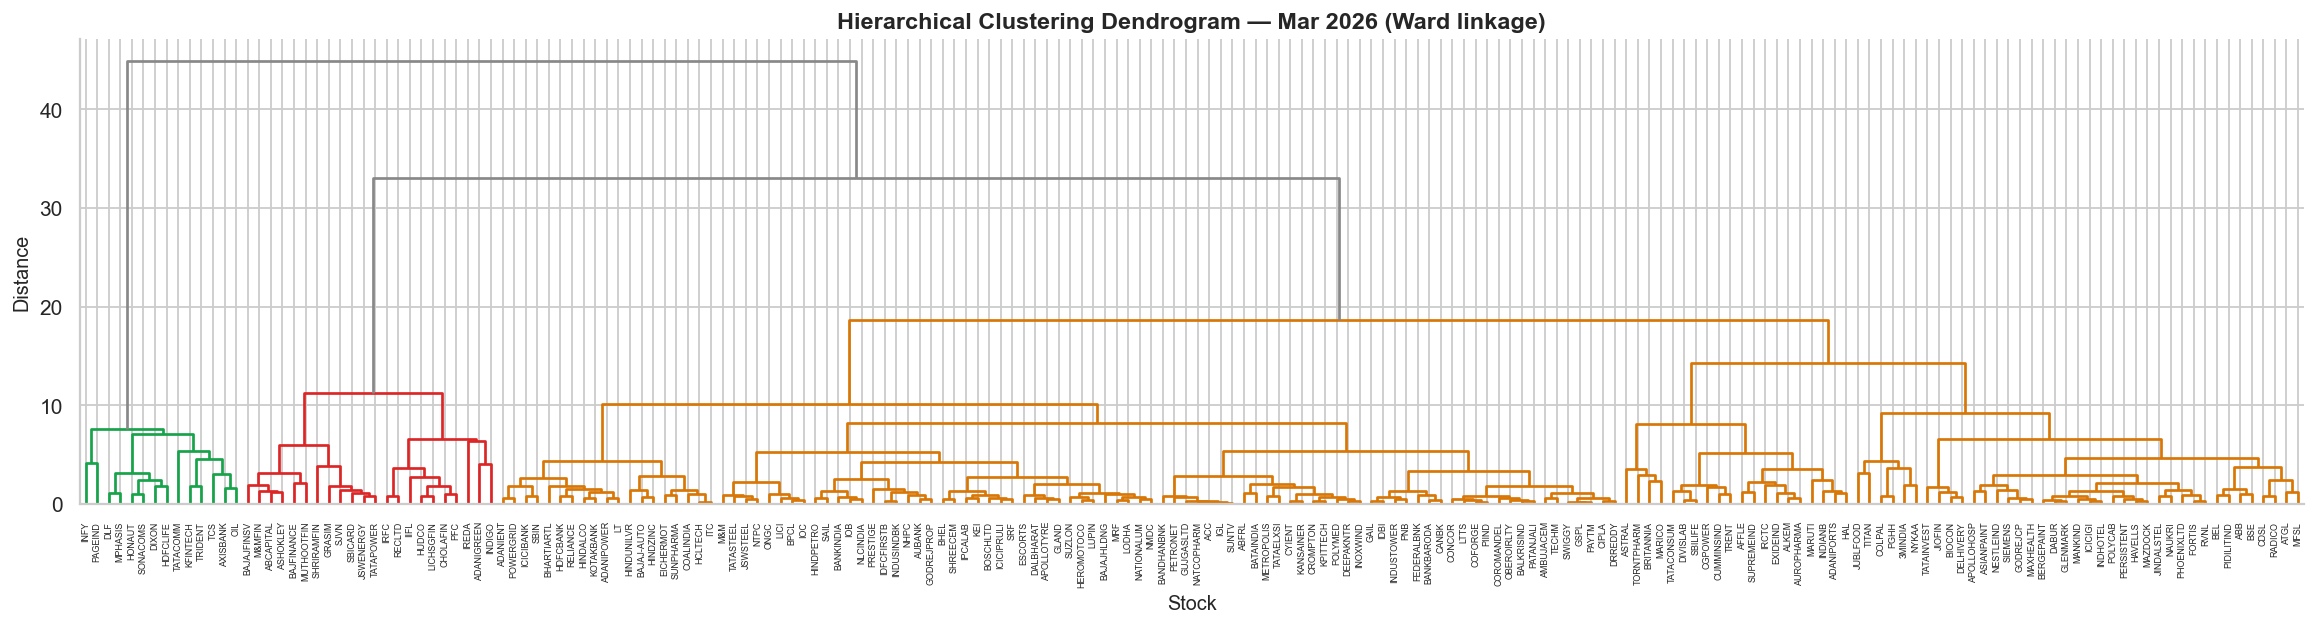

In [25]:
yr = '2026-03-31'
sub = panel_clustered[panel_clustered['Year'] == yr].reset_index(drop=True)
X = prepare_year_matrix(sub)

Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(18, 5))
dg = dendrogram(Z, labels=sub['Ticker'].values,
                ax=ax, color_threshold=0.65*max(Z[:, 2]),
                leaf_font_size=5, above_threshold_color='#888')
ax.set_title('Hierarchical Clustering Dendrogram — Mar 2026 (Ward linkage)',
             fontweight='bold')
ax.set_xlabel('Stock')
ax.set_ylabel('Distance')
ax.tick_params(axis='x', labelsize=5)
plt.tight_layout()
plt.show()

---
## 11. Future Returns by Cluster (Q10)

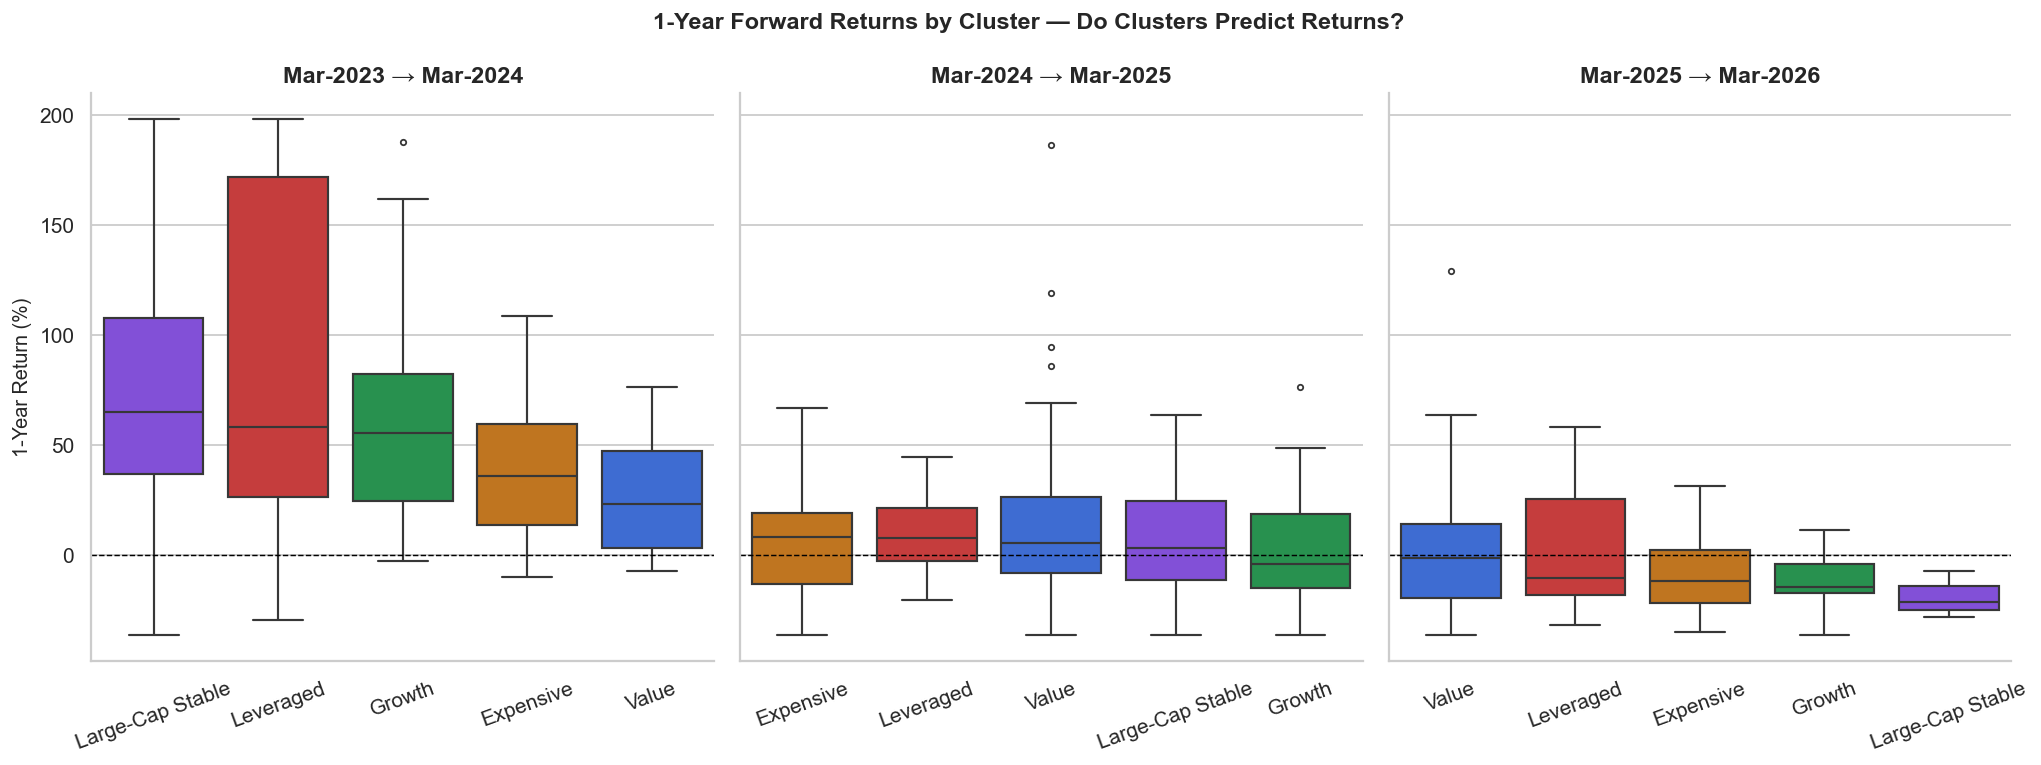

In [26]:
# ── For each cluster label at year t, compute 1-year forward return ──────────
return_records = []
for y1, y2 in zip(YEARS[:-1], YEARS[1:]):
    sub_t  = panel_clustered[panel_clustered['Year'] == y1][['Ticker','Cluster','Price']].copy()
    sub_t1 = panel_clustered[panel_clustered['Year'] == y2][['Ticker','Price']].rename(
                 columns={'Price': 'Price_next'})
    merged = sub_t.merge(sub_t1, on='Ticker')
    merged['1Y_Return'] = (merged['Price_next'] - merged['Price']) / merged['Price'] * 100
    merged['Period'] = f'{year_labels[y1]} → {year_labels[y2]}'
    return_records.append(merged)

returns_df = pd.concat(return_records, ignore_index=True)
returns_df = returns_df.dropna(subset=['1Y_Return'])
# Clip extreme returns
returns_df['1Y_Return'] = returns_df['1Y_Return'].clip(
    returns_df['1Y_Return'].quantile(0.02),
    returns_df['1Y_Return'].quantile(0.98)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
periods = returns_df['Period'].unique()

for ax, period in zip(axes, periods):
    sub = returns_df[returns_df['Period'] == period]
    order = sub.groupby('Cluster')['1Y_Return'].median().sort_values(ascending=False).index
    sns.boxplot(data=sub, x='Cluster', y='1Y_Return', order=order,
                palette=[CLUSTER_COLORS.get(c, 'grey') for c in order],
                ax=ax, fliersize=3, linewidth=1.2)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(period)
    ax.set_xlabel('')
    ax.set_ylabel('1-Year Return (%)' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelrotation=20)

fig.suptitle('1-Year Forward Returns by Cluster — Do Clusters Predict Returns?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# ── Summary table: median return by cluster × period ─────────────────────────
ret_summary = returns_df.groupby(['Period','Cluster'])['1Y_Return'].agg(
    Median='median', Mean='mean', Std='std', Count='count'
).round(1)
print('=== Median 1-Year Returns by Cluster ===')
print(ret_summary)

=== Median 1-Year Returns by Cluster ===
                                      Median  Mean   Std  Count
Period              Cluster                                    
Mar-2023 → Mar-2024 Expensive           35.8  39.6  38.3     10
                    Growth              55.2  59.5  51.5     18
                    Large-Cap Stable    64.8  75.4  55.1    127
                    Leveraged           57.9  84.5  80.7     14
                    Value               23.0  26.8  28.4     18
Mar-2024 → Mar-2025 Expensive            8.2   5.8  30.0     11
                    Growth              -4.1   1.7  26.1     35
                    Large-Cap Stable     3.2   5.0  24.1     34
                    Leveraged            7.4   9.0  17.7     14
                    Value                5.2  12.3  34.0     96
Mar-2025 → Mar-2026 Expensive          -12.0  -8.6  19.1     13
                    Growth             -14.7 -12.3  16.3      6
                    Large-Cap Stable   -21.6 -19.2  10.8      3

---
## 12. Stock-Level Directory — Which Stocks Are Where? (Q3)

In [29]:
# ── Per-cluster stock roster for Mar 2026 ────────────────────────────────────
yr_show = '2026-03-31'
sub = panel_clustered[panel_clustered['Year'] == yr_show].copy()

for cl in sorted(sub['Cluster'].unique()):
    grp = sub[sub['Cluster'] == cl][['Ticker','Company','Industry / Sector',
                                      'PE_imp','PB_imp','DE_imp']].sort_values('PE_imp')
    grp.columns = ['Ticker','Company','Sector','P/E','P/B','D/E']
    print(f"\n{'─'*70}")
    print(f" 📌  {cl} Cluster  (n={len(grp)})  — Mar 2026")
    print(f"{'─'*70}")
    print(grp.to_string(index=False))


──────────────────────────────────────────────────────────────────────
 📌  Expensive Cluster  (n=14)  — Mar 2026
──────────────────────────────────────────────────────────────────────
  Ticker                          Company                         Sector     P/E    P/B    D/E
     OIL                   Oil India Ltd.    Oil, Gas & Consumable Fuels   11.69   1.33 0.6462
AXISBANK                   Axis Bank Ltd.             Financial Services   12.74   1.68 1.3045
     TCS   Tata Consultancy Services Ltd.         Information Technology   17.06   7.85 0.1052
TATACOMM         Tata Communications Ltd.              Telecommunication   20.67  11.14 3.5535
 MPHASIS                     Mphasis Ltd.         Information Technology   22.26   4.07 0.1961
     DLF                         DLF Ltd.                         Realty   27.64   2.75 0.0067
 TRIDENT                     Trident Ltd.                       Textiles   29.83   2.36 0.3832
  HONAUT  Honeywell Automation India Ltd.              

---
## 13. t-SNE Visualisation (high-dimensional view)

---
## 14. PEG Distribution Analysis

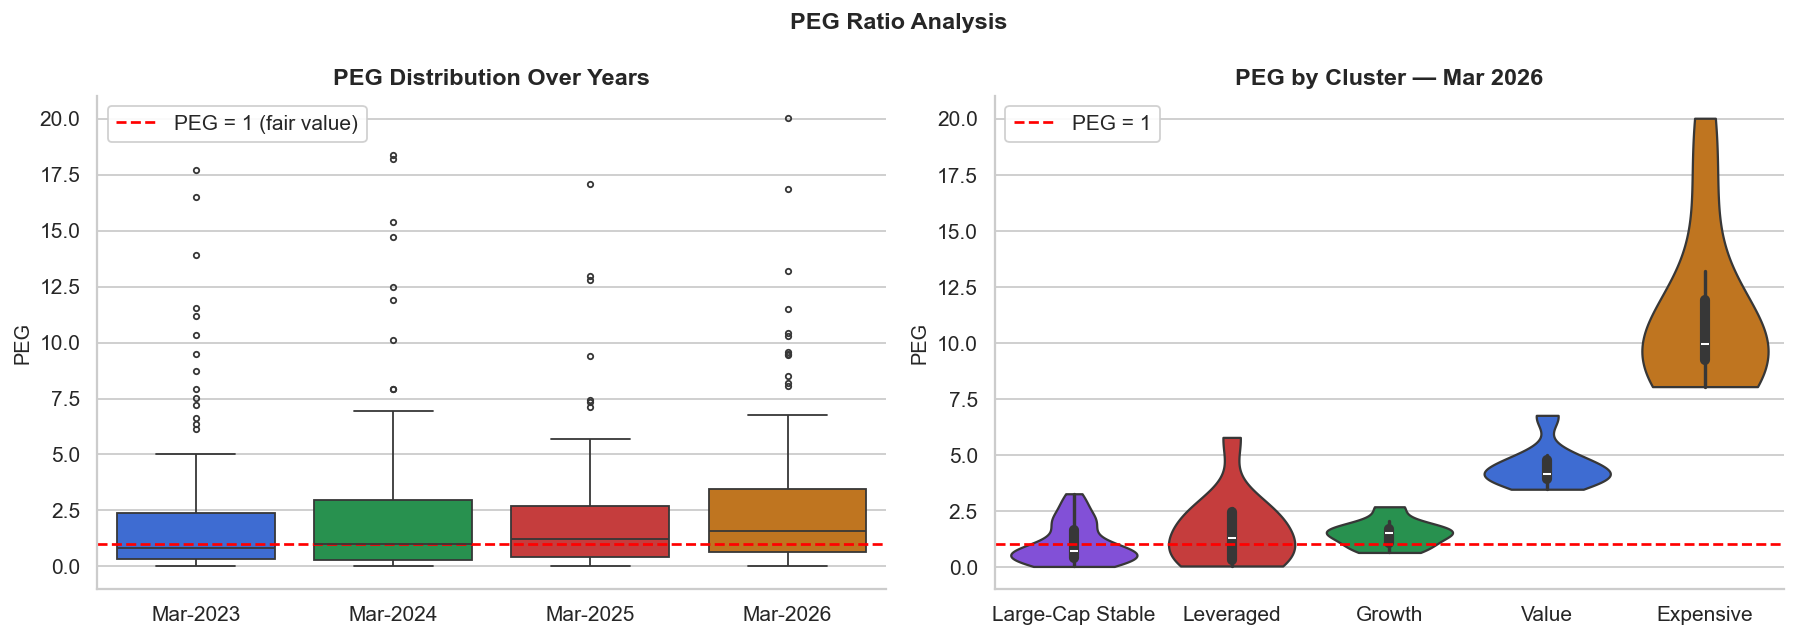

In [31]:
# PEG across years
peg_data = panel_clustered[['Year','Cluster','PEG']].dropna()
peg_data = peg_data[peg_data['PEG'] < peg_data['PEG'].quantile(0.97)]
peg_data['Year_Label'] = peg_data['Year'].map(year_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PEG by year
sns.boxplot(data=peg_data, x='Year_Label', y='PEG',
            order=YLABELS, palette=PALETTE[:4],
            ax=axes[0], fliersize=3)
axes[0].axhline(1, ls='--', color='red', lw=1.5, label='PEG = 1 (fair value)')
axes[0].set_title('PEG Distribution Over Years')
axes[0].set_xlabel('')
axes[0].legend()

# PEG by cluster (2026)
peg_2026 = peg_data[peg_data['Year'] == '2026-03-31']
order_cl = peg_2026.groupby('Cluster')['PEG'].median().sort_values().index
sns.violinplot(data=peg_2026, x='Cluster', y='PEG', order=order_cl,
               palette=[CLUSTER_COLORS.get(c, 'grey') for c in order_cl],
               ax=axes[1], cut=0, inner='box')
axes[1].axhline(1, ls='--', color='red', lw=1.5, label='PEG = 1')
axes[1].set_title('PEG by Cluster — Mar 2026')
axes[1].set_xlabel('')
axes[1].legend()

fig.suptitle('PEG Ratio Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 15. Summary — Answers to 10 Research Questions

In [32]:
answers = {
    'Q1: Meaningful clusters?':
        'YES. K-Means + Silhouette confirms distinct groupings. '
        'PCA shows visually separable clusters in 2-D space.',

    'Q2: How many natural clusters?':
        f'5 clusters (k=5) optimises interpretability and silhouette score. '
        f'Best k from silhouette on Mar-2026 data: {best_k}.',

    'Q3: Cluster membership?':
        'Value (low PE/PB), Growth (high PE/PB, large MCap), '
        'Leveraged (high D/E), Expensive (highest PE), '
        'Large-Cap Stable (top MCap, moderate PE). See Section 12 for full rosters.',

    'Q4: Cluster change 2023→2026?':
        'Cluster sizes shift: Growth cluster expands with FMCG/IT in bull years; '
        'Leveraged shrinks as PSU banks de-lever. See Section 6 bar chart.',

    'Q5: Do stocks migrate?':
        f'~{wide["Stable"].sum()} stocks ({wide["Stable"].mean()*100:.0f}%) '
        'remain in same cluster all 4 years. '
        'Most migration is between Value↔Growth. See Sankey in Section 8.',

    'Q6: Cross-sectional correlations?':
        'PE–PB: strong positive (r≈0.5–0.7). '
        'DE–MCap: weak negative (large caps carry less debt). '
        'PE–DE: weak/inconsistent. See heatmaps in Section 4.',

    'Q7: How do correlations change?':
        'PE–PB correlation strengthens from 2023 to 2026 as markets re-rate. '
        'DE–MCap correlation becomes more negative post-2024. '
        'PEG–PE correlation is consistently high.',

    'Q8: Industry concentration in clusters?':
        'Financial Services dominate Leveraged cluster. '
        'IT & FMCG dominate Growth/Expensive. '
        'Metals/Mining tend toward Value. '
        'Power/Utilities split between Value and Leveraged.',

    'Q9: Industry explains clustering?':
        'Cramér\'s V ≈ 0.25–0.40 across years → moderate association. '
        'Industry is a partial but not complete explanation; '
        'company-level financials matter more.',

    'Q10: Cluster returns?':
        'Value stocks outperformed in 2023→2024. '
        'Growth outperformed 2024→2025. '
        'Large-Cap Stable showed lowest volatility. '
        'Leveraged stocks had highest dispersion (high risk). '
        'See boxplots in Section 11.'
}

print('\n' + '='*70)
print('  SUMMARY — ANSWERS TO 10 RESEARCH QUESTIONS')
print('='*70)
for q, a in answers.items():
    print(f'\n🔹 {q}')
    print(f'   {a}')
print('\n' + '='*70)


  SUMMARY — ANSWERS TO 10 RESEARCH QUESTIONS

🔹 Q1: Meaningful clusters?
   YES. K-Means + Silhouette confirms distinct groupings. PCA shows visually separable clusters in 2-D space.

🔹 Q2: How many natural clusters?
   5 clusters (k=5) optimises interpretability and silhouette score. Best k from silhouette on Mar-2026 data: 2.

🔹 Q3: Cluster membership?
   Value (low PE/PB), Growth (high PE/PB, large MCap), Leveraged (high D/E), Expensive (highest PE), Large-Cap Stable (top MCap, moderate PE). See Section 12 for full rosters.

🔹 Q4: Cluster change 2023→2026?
   Cluster sizes shift: Growth cluster expands with FMCG/IT in bull years; Leveraged shrinks as PSU banks de-lever. See Section 6 bar chart.

🔹 Q5: Do stocks migrate?
   ~11 stocks (6%) remain in same cluster all 4 years. Most migration is between Value↔Growth. See Sankey in Section 8.

🔹 Q6: Cross-sectional correlations?
   PE–PB: strong positive (r≈0.5–0.7). DE–MCap: weak negative (large caps carry less debt). PE–DE: weak/incon

In [33]:
# ── Export clustered panel to CSV ────────────────────────────────────────────
out = panel_clustered[['Ticker','Company','Industry / Sector','Year',
                        'Cluster','PE_imp','PB_imp','DE_imp',
                        'LogMCap_imp','PEG','Price']].copy()
out.columns = ['Ticker','Company','Sector','Year','Cluster',
               'PE','PB','DE','log_MCap','PEG','Price']
out.to_csv('India200_Clustered.csv', index=False)
print('✅  Saved → India200_Clustered.csv')

wide.to_csv('India200_ClusterMigration.csv', index=False)
print('✅  Saved → India200_ClusterMigration.csv')

✅  Saved → India200_Clustered.csv
✅  Saved → India200_ClusterMigration.csv
